# RB 全合约持仓、成交量与双幂变差的协整研究

研究对象为螺纹钢（XSGE.RB），分析区间为 2015—2025 年。日内研究按固定交易窗口聚合全合约成交量、窗口末端全合约持仓量与主力合约双幂变差，先判断各序列的积分阶数，再区分常规协整、分数阶协整及短记忆相关。

## 数据与主力规则

前部读取和主力构造直接取自 `testing_10.ipynb`，重新读取正式 silver 的品种日历、合约日历、日线与原始 1 分钟行情；不读取其 Parquet 快照。日线采用分析末日以前的完整历史来初始化主力；分钟及研究样本限制在所设分析区间内。夜盘按交易所 `trading_date` 归属。

换约阈值为 **1.00**：后月候选合约在信号日的日成交量**严格大于**旧主力日成交量，才触发下一交易日换约；相等时不换约。这表示成交量比值超过 1.00，并非超过 2.00。主力只向退市日更晚的合约滚动；初始化的同量并列按持仓量、较近退市日及合约代码排序。旧主力下一交易日不再挂牌或缺少有效成交量时，单独记录例外原因。

全合约持仓和成交量由真实合约原始行情聚合；主力映射仅用于选取 BV 的价格序列。所有上游只读，不调用行情 API，不写入正式湖。

文件输出：图表和表格默认保留在 Notebook 内。`EXPORT_FILES = True` 时，独立图片、JSON 及窗口数据统一保存到 `testing_14/`；默认运行不创建这些独立文件。

In [1]:
EXCHANGE_CODE = "XSGE"
UNDERLYING_CODE = "RB"
START_DATE = "2015-01-01"
END_DATE = "2025-12-31"
ROLL_TRIGGER_RATIO = 1.00

## 1. 项目环境与权威数据契约

In [2]:
from __future__ import annotations

import math
import pathlib
import sys
from datetime import date

import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Market_Data/a01_Collection"))
        break
else:
    raise RuntimeError("未找到项目根目录；请从 E:\\Latitude_Analytics_v2 内启动 Notebook。")

from config.data_contracts import (  # noqa: E402
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_DAILY_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from config.settings import settings  # noqa: E402
from b00_03_notebook_schema_browser import display_schema_metadata  # noqa: E402

print(f"解释器：{sys.executable}")
notebook_dir = candidate_root / "00_draft_collection_01"
output_dir = notebook_dir / "testing_14"
EXPORT_FILES = False  # 图表默认内嵌；需要独立文件时显式设为 True。
if EXPORT_FILES:
    output_dir.mkdir(parents=True, exist_ok=True)

SILVER_ROOT = settings.futures_lake_root / "silver"
SILVER_SCHEMAS = (
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_DAILY_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
)
SILVER_TABLE_NAMES = [schema.metadata[b"table_name"].decode("utf-8") for schema in SILVER_SCHEMAS]
(
    VARIETY_CALENDAR_TABLE_NAME, CONTRACT_CALENDAR_TABLE_NAME,
    DAILY_TABLE_NAME, MINUTE_TABLE_NAME,
) = SILVER_TABLE_NAMES
SILVER_TABLE_INFO = {
    table_name: {
        "schema": schema,
        "primary_key": schema.metadata[b"primary_key"].decode("utf-8").split(","),
        "partition_columns": schema.metadata[b"partition_columns"].decode("utf-8").split(","),
    }
    for table_name, schema in zip(SILVER_TABLE_NAMES, SILVER_SCHEMAS)
}


def read_silver(table_name: str, filter_expression: ds.Expression) -> pd.DataFrame:
    table_info = SILVER_TABLE_INFO[table_name]
    schema = table_info["schema"]
    table_path = SILVER_ROOT / table_name
    if not table_path.is_dir():
        raise FileNotFoundError(f"silver 数据集不存在：{table_path}")
    partition_schema = pa.schema(
        [schema.field(name) for name in table_info["partition_columns"]]
    )
    dataset = ds.dataset(
        table_path,
        format="parquet",
        schema=schema,
        partitioning=ds.partitioning(partition_schema, flavor="hive"),
    )
    expected_fields = [field for field in schema if field.name not in table_info["partition_columns"]]
    # 检查所读分片的物理契约；历史描述性 metadata 以当前权威说明为准。
    for fragment in dataset.get_fragments(filter=filter_expression):
        physical_schema = fragment.physical_schema
        physical_fields = [
            field for field in physical_schema if field.name not in table_info["partition_columns"]
        ]
        if not pa.schema(physical_fields).equals(pa.schema(expected_fields), check_metadata=False):
            raise ValueError(f"输入物理结构不兼容：{fragment.path}")
        for name in table_info["partition_columns"]:
            if name in physical_schema.names and not physical_schema.field(name).equals(
                schema.field(name), check_metadata=False,
            ):
                raise ValueError(f"输入分区字段不兼容：{fragment.path} / {name}")
        for metadata_key in (b"table_name", b"primary_key", b"partition_columns", b"schema_version"):
            if (physical_schema.metadata or {}).get(metadata_key) != schema.metadata[metadata_key]:
                raise ValueError(f"输入表身份或契约版本不兼容：{fragment.path}")
    table = dataset.to_table(columns=schema.names, filter=filter_expression)
    return arrow_to_pandas(validate_arrow_table(table, schema), schema)


def parse_request_dates(start_date: str, end_date: str) -> tuple[date, date]:
    try:
        start = date.fromisoformat(start_date)
        end = date.fromisoformat(end_date)
    except ValueError as error:
        raise ValueError("START_DATE 和 END_DATE 必须是 YYYY-MM-DD。") from error
    if start > end:
        raise ValueError("START_DATE 不得晚于 END_DATE。")
    return start, end

解释器：E:\anaconda3\envs\latitude_env_v2\python.exe


In [3]:
display_schema_metadata(list(SILVER_SCHEMAS))

## 2. 使用完整历史识别日级主力

信号日成交量只决定下一交易日；初始并列按持仓量、较近退市日、合约代码排序。后续只向退市日更晚的合约滚动，要求挑战者成交量严格超过现主力的 1.00 倍。若现主力退市且没有有效后月候选，该交易日不生成主力映射。

信任正式提交的上游业务质量；物理字段、类型、nullable 及表身份在读取时核对。主力映射是本研究派生结果，另核对其交易日唯一性。

In [4]:
def load_daily_inputs(
    exchange_code: str, underlying_code: str, end_date: date
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    variety_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("year") <= end_date.year)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("trading_date") <= end_date)
    )
    fact_filter = variety_filter
    variety_calendar_df = read_silver(VARIETY_CALENDAR_TABLE_NAME, variety_filter)
    contract_calendar_df = read_silver(CONTRACT_CALENDAR_TABLE_NAME, variety_filter)
    daily_df = read_silver(DAILY_TABLE_NAME, fact_filter)
    return variety_calendar_df, contract_calendar_df, daily_df


def build_main_contract_daily(
    variety_calendar_df: pd.DataFrame,
    contract_calendar_df: pd.DataFrame,
    daily_df: pd.DataFrame,
    roll_trigger_ratio: float,
) -> pd.DataFrame:
    if not math.isfinite(roll_trigger_ratio) or roll_trigger_ratio < 1:
        raise ValueError("ROLL_TRIGGER_RATIO 必须是大于或等于 1 的有限数。")

    output_columns = [
        "exchange_code", "underlying_code", "trading_date", "signal_trading_date",
        "main_contract_code", "previous_main_contract_code", "continuity_segment",
        "is_roll", "selection_reason", "main_contract_signal_volume",
        "incumbent_signal_volume", "challenger_contract_code",
        "challenger_signal_volume", "roll_trigger_ratio",
    ]
    if variety_calendar_df.empty:
        return pd.DataFrame(columns=output_columns)

    key_columns = ["exchange_code", "underlying_code", "trading_date"]
    trading_dates = sorted(variety_calendar_df["trading_date"].drop_duplicates().tolist())
    contract_dates_df = (
        contract_calendar_df[
            ["contract_code", *key_columns, "delist_date", "session_number"]
        ]
        .sort_values([*key_columns, "contract_code", "session_number"])
        .drop_duplicates([*key_columns, "contract_code"], keep="first")
        .drop(columns="session_number")
    )
    daily_work_df = daily_df[
        ["contract_code", *key_columns, "volume", "open_interest", "has_market_data"]
    ].copy()
    candidate_history_df = daily_work_df.merge(
        contract_dates_df,
        how="left",
        on=["contract_code", *key_columns],
        validate="one_to_one",
    )
    ranked_df = candidate_history_df.loc[
        candidate_history_df["has_market_data"].fillna(False)
        & candidate_history_df["volume"].notna()
        & (candidate_history_df["volume"] > 0)
    ].copy()
    ranked_df["open_interest_rank"] = pd.to_numeric(
        ranked_df["open_interest"], errors="coerce"
    ).fillna(-math.inf)
    ranked_df = ranked_df.sort_values(
        ["trading_date", "volume", "open_interest_rank", "delist_date", "contract_code"],
        ascending=[True, False, False, True, True],
        kind="mergesort",
    )
    ranked_candidates_by_date = {
        trading_date: group_df.to_dict("records")
        for trading_date, group_df in ranked_df.groupby("trading_date", sort=False)
    }
    delist_lookup = contract_dates_df.groupby("contract_code")["delist_date"].max().to_dict()
    active_codes_by_date = {
        trading_date: set(group_df["contract_code"].astype(str))
        for trading_date, group_df in contract_dates_df.groupby("trading_date")
    }

    rows = []
    main_contract_code = None
    continuity_segment = 0
    for signal_index, signal_trading_date in enumerate(trading_dates[:-1]):
        trading_date = trading_dates[signal_index + 1]
        ranked_candidates = ranked_candidates_by_date.get(signal_trading_date, [])
        target_active_codes = active_codes_by_date.get(trading_date, set())
        eligible_candidates = [
            candidate for candidate in ranked_candidates
            if str(candidate["contract_code"]) in target_active_codes
        ]
        previous_main_contract_code = main_contract_code
        incumbent_signal_volume = None
        challenger_contract_code = None
        challenger_signal_volume = None

        if main_contract_code is None:
            if not eligible_candidates:
                continue
            continuity_segment += 1
            main_contract_code = str(eligible_candidates[0]["contract_code"])
            selection_reason = "bootstrap_previous_day_volume_leader"
            later_candidates = [
                candidate for candidate in eligible_candidates
                if str(candidate["contract_code"]) != main_contract_code
            ]
            if later_candidates:
                challenger_contract_code = str(later_candidates[0]["contract_code"])
                challenger_signal_volume = float(later_candidates[0]["volume"])
        else:
            incumbent_candidate = next(
                (candidate for candidate in ranked_candidates
                 if str(candidate["contract_code"]) == main_contract_code),
                None,
            )
            if incumbent_candidate is not None:
                incumbent_signal_volume = float(incumbent_candidate["volume"])
            incumbent_delist_date = delist_lookup.get(main_contract_code)
            challenger_candidates = [
                candidate for candidate in eligible_candidates
                if str(candidate["contract_code"]) != main_contract_code
                and (
                    incumbent_delist_date is None
                    or (
                        pd.notna(candidate["delist_date"])
                        and candidate["delist_date"] > incumbent_delist_date
                    )
                )
            ]
            if challenger_candidates:
                challenger_contract_code = str(challenger_candidates[0]["contract_code"])
                challenger_signal_volume = float(challenger_candidates[0]["volume"])

            if main_contract_code not in target_active_codes:
                if challenger_contract_code is None:
                    main_contract_code = None
                    continue
                main_contract_code = challenger_contract_code
                selection_reason = "incumbent_not_active_next_trading_date"
            elif incumbent_signal_volume is None:
                if challenger_contract_code is None:
                    selection_reason = "no_valid_volume_keep_incumbent"
                else:
                    main_contract_code = challenger_contract_code
                    selection_reason = "incumbent_market_data_missing"
            elif (
                challenger_signal_volume is not None
                and challenger_signal_volume > incumbent_signal_volume * roll_trigger_ratio
            ):
                main_contract_code = challenger_contract_code
                selection_reason = "challenger_volume_threshold"
            else:
                selection_reason = "incumbent_retained"

        selected_candidate = next(
            (candidate for candidate in ranked_candidates
             if str(candidate["contract_code"]) == main_contract_code),
            None,
        )
        rows.append({
            "exchange_code": str(variety_calendar_df["exchange_code"].iloc[0]),
            "underlying_code": str(variety_calendar_df["underlying_code"].iloc[0]),
            "trading_date": trading_date,
            "signal_trading_date": signal_trading_date,
            "main_contract_code": main_contract_code,
            "previous_main_contract_code": previous_main_contract_code,
            "continuity_segment": continuity_segment,
            "is_roll": previous_main_contract_code is not None
            and main_contract_code != previous_main_contract_code,
            "selection_reason": selection_reason,
            "main_contract_signal_volume": None if selected_candidate is None
            else float(selected_candidate["volume"]),
            "incumbent_signal_volume": incumbent_signal_volume,
            "challenger_contract_code": challenger_contract_code,
            "challenger_signal_volume": challenger_signal_volume,
            "roll_trigger_ratio": float(roll_trigger_ratio),
        })

    mapping_df = pd.DataFrame(rows, columns=output_columns)
    if mapping_df.duplicated(key_columns).any():
        raise ValueError("主力映射存在重复交易日。")
    return mapping_df

## 3. 分区读取当日主力的分钟行情

每次只读请求范围内的品种年月分区，并以 `trading_date + contract_code` 精确匹配日级主力。
若某个主力交易日无分钟记录，保留在日级映射表中，不制造缺失 bar。

In [5]:
def month_pairs(start_date: date, end_date: date) -> list[tuple[int, int]]:
    pairs = []
    year, month = start_date.year, start_date.month
    while (year, month) <= (end_date.year, end_date.month):
        pairs.append((year, month))
        year, month = (year + 1, 1) if month == 12 else (year, month + 1)
    return pairs


def load_main_minute_bars(
    exchange_code: str,
    underlying_code: str,
    start_date: str,
    end_date: str,
    roll_trigger_ratio: float = 1.00,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    requested_start, requested_end = parse_request_dates(start_date, end_date)
    exchange_code = exchange_code.strip().upper()
    underlying_code = underlying_code.strip().upper()
    if not exchange_code or not underlying_code:
        raise ValueError("必须指定交易所和品种代码。")

    variety_calendar_df, contract_calendar_df, daily_df = load_daily_inputs(
        exchange_code, underlying_code, requested_end
    )
    if variety_calendar_df.empty:
        raise ValueError(f"品种日历没有 {exchange_code}.{underlying_code} 的交易日。")
    all_mapping_df = build_main_contract_daily(
        variety_calendar_df, contract_calendar_df, daily_df, roll_trigger_ratio
    )
    mapping_df = all_mapping_df.loc[
        (all_mapping_df["trading_date"] >= requested_start)
        & (all_mapping_df["trading_date"] <= requested_end)
    ].copy()
    if mapping_df.empty:
        raise ValueError("所选范围没有可识别的主力合约；请检查日期、日线覆盖和流动性。")

    minute_frames = []
    for year, month in month_pairs(requested_start, requested_end):
        month_mapping_df = mapping_df.loc[
            (mapping_df["trading_date"].map(lambda day: day.year) == year)
            & (mapping_df["trading_date"].map(lambda day: day.month) == month)
        ]
        if month_mapping_df.empty:
            continue
        selected_codes = month_mapping_df["main_contract_code"].unique().tolist()
        minute_filter = (
            (ds.field("exchange_code") == exchange_code)
            & (ds.field("underlying_code") == underlying_code)
            & (ds.field("year") == year)
            & (ds.field("month") == month)
            & (ds.field("trading_date") >= requested_start)
            & (ds.field("trading_date") <= requested_end)
            & ds.field("contract_code").isin(selected_codes)
        )
        month_minute_df = read_silver(MINUTE_TABLE_NAME, minute_filter)
        if not month_minute_df.empty:
            minute_frames.append(month_minute_df)

    if minute_frames:
        minute_df = pd.concat(minute_frames, ignore_index=True)
        main_minute_df = minute_df.merge(
            mapping_df,
            how="inner",
            left_on=["exchange_code", "underlying_code", "trading_date", "contract_code"],
            right_on=["exchange_code", "underlying_code", "trading_date", "main_contract_code"],
            validate="many_to_one",
        )
        if main_minute_df.duplicated(["contract_code", "bar_at"]).any():
            raise ValueError("返回的分钟行情存在重复主键。")
        main_minute_df = main_minute_df.sort_values(
            ["bar_at", "contract_code"], kind="mergesort"
        ).reset_index(drop=True)
    else:
        main_minute_df = pd.DataFrame(columns=[
            *FUTURES_MINUTE_SCHEMA.names,
            *[column for column in mapping_df.columns
              if column not in FUTURES_MINUTE_SCHEMA.names],
        ])
    return (
        mapping_df.reset_index(drop=True), main_minute_df,
        variety_calendar_df, contract_calendar_df, daily_df,
    )

## 4. 执行并查看结果

In [6]:
(
    main_contract_daily_df, main_minute_df,
    variety_calendar_df, contract_calendar_df, daily_df,
) = load_main_minute_bars(
    EXCHANGE_CODE,
    UNDERLYING_CODE,
    START_DATE,
    END_DATE,
    ROLL_TRIGGER_RATIO,
)

minute_counts_df = (
    main_minute_df.groupby("trading_date").size().rename("minute_count").reset_index()
    if not main_minute_df.empty
    else pd.DataFrame(columns=["trading_date", "minute_count"])
)
main_contract_coverage_df = main_contract_daily_df.merge(
    minute_counts_df, on="trading_date", how="left", validate="one_to_one"
)
main_contract_coverage_df["minute_count"] = (
    main_contract_coverage_df["minute_count"].fillna(0).astype(int)
)
print(
    f"{EXCHANGE_CODE}.{UNDERLYING_CODE} {START_DATE} ~ {END_DATE}: "
    f"主力交易日 {len(main_contract_daily_df)}，分钟记录 {len(main_minute_df)}"
)
if main_minute_df.empty:
    raise ValueError("所选范围没有主力分钟数据，不能计算 BV。")
display(main_contract_coverage_df.head())
display(main_contract_daily_df.loc[
    main_contract_daily_df["is_roll"],
    ["signal_trading_date", "trading_date", "previous_main_contract_code", "main_contract_code",
     "incumbent_signal_volume", "challenger_signal_volume", "selection_reason"],
])

XSGE.RB 2015-01-01 ~ 2025-12-31: 主力交易日 2674，分钟记录 943770


,exchange_code,underlying_code,trading_date,signal_trading_date,main_contract_code,previous_main_contract_code,continuity_segment,is_roll,selection_reason,main_contract_signal_volume,incumbent_signal_volume,challenger_contract_code,challenger_signal_volume,roll_trigger_ratio,minute_count
0,XSGE,RB,2015-01-05,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.0,225
1,XSGE,RB,2015-01-06,2015-01-05,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,2891694.0,2891694.0,RB1510.XSGE,159400.0,1.0,465
2,XSGE,RB,2015-01-07,2015-01-06,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,7434538.0,7434538.0,RB1510.XSGE,381522.0,1.0,465
3,XSGE,RB,2015-01-08,2015-01-07,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4317868.0,4317868.0,RB1510.XSGE,244838.0,1.0,465
4,XSGE,RB,2015-01-09,2015-01-08,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,3696668.0,3696668.0,RB1510.XSGE,191572.0,1.0,465


,signal_trading_date,trading_date,previous_main_contract_code,main_contract_code,incumbent_signal_volume,challenger_signal_volume,selection_reason
37,2015-03-03,2015-03-04,RB1505.XSGE,RB1510.XSGE,1199714.0,1818088.0,challenger_volume_threshold
129,2015-07-14,2015-07-15,RB1510.XSGE,RB1601.XSGE,1806312.0,2608720.0,challenger_volume_threshold
202,2015-11-03,2015-11-04,RB1601.XSGE,RB1605.XSGE,1032118.0,1411662.0,challenger_volume_threshold
289,2016-03-11,2016-03-14,RB1605.XSGE,RB1610.XSGE,4663174.0,5421854.0,challenger_volume_threshold
398,2016-08-17,2016-08-18,RB1610.XSGE,RB1701.XSGE,3099566.0,3885986.0,challenger_volume_threshold
464,2016-11-28,2016-11-29,RB1701.XSGE,RB1705.XSGE,2076172.0,2733408.0,challenger_volume_threshold
538,2017-03-20,2017-03-21,RB1705.XSGE,RB1710.XSGE,1887018.0,2693626.0,challenger_volume_threshold
632,2017-08-04,2017-08-07,RB1710.XSGE,RB1801.XSGE,3464504.0,4499920.0,challenger_volume_threshold
690,2017-11-01,2017-11-02,RB1801.XSGE,RB1805.XSGE,2340156.0,2353544.0,challenger_volume_threshold
790,2018-03-29,2018-03-30,RB1805.XSGE,RB1810.XSGE,2241628.0,3252386.0,challenger_volume_threshold


## 5. 构造主力对数价格

在换约信号日或其之前，取新旧合约最近共同有效日收盘价之对数差，按换约日累加到分钟价格上。`backward_adjusted_log_close` 锚定序列首端，`forward_adjusted_log_close` 锚定末端。

后续 BV 使用同一交易时段内的分钟对数收益；禁止把跨交易日或跨休市间隔的价差伪装成单分钟收益。复权调整在同一交易日内为常数，不改变该日内部相邻分钟的对数收益。

In [7]:
import numpy as np

# 1. 从本 Notebook 已重新读取的原始日线中选取换月合约收盘价
roll_daily_df = main_contract_daily_df.loc[
    main_contract_daily_df["is_roll"]
    & (main_contract_daily_df["trading_date"] > main_minute_df["trading_date"].iloc[0])
    & (main_contract_daily_df["trading_date"] <= main_minute_df["trading_date"].iloc[-1])
]

roll_contract_codes = roll_daily_df[
    ["previous_main_contract_code", "main_contract_code"]
].stack().unique()

daily_price_df = daily_df.loc[
    daily_df["contract_code"].isin(roll_contract_codes)
    & (daily_df["trading_date"] <= roll_daily_df["signal_trading_date"].max())
].copy()

daily_close_df = daily_price_df.loc[
    daily_price_df["has_market_data"] & (daily_price_df["close"] > 0)
].pivot(index="trading_date", columns="contract_code", values="close").sort_index()

# 2. 每次换月计算同日价差，再按日累加
roll_log_gap = pd.Series(0.0, index=main_contract_daily_df["trading_date"])

for roll in roll_daily_df.itertuples(index=False):
    common_close = daily_close_df.loc[
        :roll.signal_trading_date,
        [roll.previous_main_contract_code, roll.main_contract_code],
    ].dropna()
    if common_close.empty:
        raise ValueError(f"换约前没有共同有效收盘价：{roll.previous_main_contract_code} / {roll.main_contract_code}")
    common_close = common_close.iloc[-1]

    roll_log_gap.loc[roll.trading_date] = (
        np.log(common_close.iloc[1]) - np.log(common_close.iloc[0])
    )

cumulative_log_gap = main_minute_df["trading_date"].map(
    roll_log_gap.sort_index().cumsum()
)

# 3. 分别锚定首、尾 close
log_close = np.log(main_minute_df["close"])
main_minute_df["backward_adjusted_log_close"] = log_close - cumulative_log_gap
main_minute_df["forward_adjusted_log_close"] = (
    log_close - cumulative_log_gap + cumulative_log_gap.iloc[-1]
)

display(main_minute_df.head())

,contract_code,exchange_code,underlying_code,trading_date,session_number,bar_at,open,high,low,close,volume,money,open_interest,source,updated_at,year,month,signal_trading_date,main_contract_code,previous_main_contract_code,continuity_segment,is_roll,selection_reason,main_contract_signal_volume,incumbent_signal_volume,challenger_contract_code,challenger_signal_volume,roll_trigger_ratio,backward_adjusted_log_close,forward_adjusted_log_close
0,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:01:00+08:00,2550.0,2556.0,2546.0,2554.0,119038.0,3036040820.0,2119948.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.0,7.845416,7.344046
1,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:02:00+08:00,2555.0,2560.0,2555.0,2557.0,73354.0,1876008000.0,2124524.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.0,7.84659,7.34522
2,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:03:00+08:00,2556.0,2558.0,2555.0,2557.0,37466.0,957780520.0,2124716.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.0,7.84659,7.34522
3,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:04:00+08:00,2556.0,2562.0,2556.0,2559.0,50016.0,1280375660.0,2127546.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.0,7.847372,7.346002
4,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:05:00+08:00,2559.0,2559.0,2556.0,2556.0,34832.0,890741660.0,2131518.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.0,7.846199,7.344829


## 6. 固定日盘窗口与全合约分钟聚合

主频为 **30 分钟**：窗口终点固定为 09:30、10:00、11:00、11:30、14:00、14:30、15:00；每个窗口均为右闭区间，例如 `(09:00, 09:30]`。敏感性频率为 **60 分钟**：终点为 10:00、11:30、14:30，对应 `(09:00, 10:00]`、`(10:30, 11:30]`、`(13:30, 14:30]`。不跨午休、盘中休市或夜盘拼接窗口。

- 成交量：先将每分钟所有已记录真实合约成交量求和，再将窗口内的分钟总量求和；必须存在全部预期分钟且这些分钟总量均非空。
- 持仓量：仅取窗口**终点**所有已记录真实合约的持仓量之和，不沿时间累加持仓。
- 任一已记录合约该字段缺失，则对应分钟总量为缺失。合约记录数另列；它描述已记录合约覆盖，不等同于证明不存在整条合约记录缺失。
- 主力 BV：仅用窗口内连续 30 或 60 条有效正收盘价，先计算 $r_i=\log P_i-\log P_{i-1}$，再计算 $BV=(\pi/2)\sum_{i=3}^{w}|r_{i-1}||r_i|$。因此有效收益乘积数为 $w-2$。不跨窗口借用首个收益，不作年化或有限样本放大。

结果保留“主力映射交易日 × 固定时段”的完整网格。没有足够数据的窗口保留缺失值，零值原样保留；对数分析另用三个指标均为正的 `positive_log_mask`。

In [8]:
import time
import pyarrow.parquet as pq

WINDOW_SLOTS_BY_WIDTH = {
    30: ("09:30", "10:00", "11:00", "11:30", "14:00", "14:30", "15:00"),
    60: ("10:00", "11:30", "14:30"),
}
requested_start, requested_end = parse_request_dates(START_DATE, END_DATE)
all_contract_minute_totals = []
read_started_at = time.perf_counter()
requested_months = month_pairs(requested_start, requested_end)
for month_number, (year, month) in enumerate(requested_months, start=1):
    all_contract_minute_filter = (
        (ds.field("exchange_code") == EXCHANGE_CODE)
        & (ds.field("underlying_code") == UNDERLYING_CODE)
        & (ds.field("year") == year)
        & (ds.field("month") == month)
        & (ds.field("trading_date") >= requested_start)
        & (ds.field("trading_date") <= requested_end)
    )
    all_contract_month_df = read_silver(MINUTE_TABLE_NAME, all_contract_minute_filter)
    if not all_contract_month_df.empty:
        # 聚合只需日盘；bar_at 保留上海时区，trading_date 保留交易所归属。
        all_contract_month_df = all_contract_month_df[
            ["trading_date", "bar_at", "contract_code", "volume", "open_interest"]
        ].copy()
        all_contract_month_df["bar_at"] = pd.to_datetime(all_contract_month_df["bar_at"])
        minute_clock = (
            all_contract_month_df["bar_at"].dt.hour * 60
            + all_contract_month_df["bar_at"].dt.minute
        )
        all_contract_month_df = all_contract_month_df.loc[
            minute_clock.gt(9 * 60) & minute_clock.le(15 * 60)
            & all_contract_month_df["bar_at"].dt.date.eq(all_contract_month_df["trading_date"])
        ].copy()
        for field in ["volume", "open_interest"]:
            all_contract_month_df[field] = all_contract_month_df[field].to_numpy(dtype="float64", na_value=np.nan)
        grouped_minutes = all_contract_month_df.groupby(["trading_date", "bar_at"], sort=True)
        month_minute_totals_df = grouped_minutes.agg(
            total_volume=("volume", "sum"),
            total_open_interest=("open_interest", "sum"),
            contract_count=("contract_code", "size"),
            volume_contract_count=("volume", "count"),
            open_interest_contract_count=("open_interest", "count"),
        ).reset_index()
        month_minute_totals_df.loc[
            month_minute_totals_df["volume_contract_count"].ne(month_minute_totals_df["contract_count"]),
            "total_volume",
        ] = np.nan
        month_minute_totals_df.loc[
            month_minute_totals_df["open_interest_contract_count"].ne(month_minute_totals_df["contract_count"]),
            "total_open_interest",
        ] = np.nan
        all_contract_minute_totals.append(month_minute_totals_df)
    if month_number % 12 == 0 or month_number == len(requested_months):
        print(f"全合约分钟读取 {month_number}/{len(requested_months)} 月，已到 {year}-{month:02d}；耗时 {time.perf_counter() - read_started_at:.1f} 秒", flush=True)

all_contract_minute_totals_df = pd.concat(all_contract_minute_totals, ignore_index=True)
del all_contract_minute_totals, all_contract_month_df
print(f"全合约日盘分钟聚合行数：{len(all_contract_minute_totals_df):,}")
display(all_contract_minute_totals_df.head())

全合约分钟读取 12/132 月，已到 2015-12；耗时 19.7 秒


全合约分钟读取 24/132 月，已到 2016-12；耗时 37.8 秒


全合约分钟读取 36/132 月，已到 2017-12；耗时 55.3 秒


全合约分钟读取 48/132 月，已到 2018-12；耗时 73.1 秒


全合约分钟读取 60/132 月，已到 2019-12；耗时 90.7 秒


...

全合约分钟读取 108/132 月，已到 2023-12；耗时 158.1 秒


全合约分钟读取 120/132 月，已到 2024-12；耗时 175.3 秒


全合约分钟读取 132/132 月，已到 2025-12；耗时 192.2 秒


全合约日盘分钟聚合行数：601,650


,trading_date,bar_at,total_volume,total_open_interest,contract_count,volume_contract_count,open_interest_contract_count
0,2015-01-05,2015-01-05 09:01:00+08:00,130328.0,2525556.0,12,12,12
1,2015-01-05,2015-01-05 09:02:00+08:00,80736.0,2530916.0,12,12,12
2,2015-01-05,2015-01-05 09:03:00+08:00,40884.0,2532132.0,12,12,12
3,2015-01-05,2015-01-05 09:04:00+08:00,52602.0,2535120.0,12,12,12
4,2015-01-05,2015-01-05 09:05:00+08:00,36208.0,2539004.0,12,12,12


In [9]:
main_price_df = main_minute_df[["trading_date", "bar_at", "close"]].copy()
main_price_df["bar_at"] = pd.to_datetime(main_price_df["bar_at"])
main_price_df["close"] = main_price_df["close"].to_numpy(dtype="float64", na_value=np.nan)
main_price_df["main_minute_present"] = True
intraday_frames_by_width = {}
coverage_summary_rows = []

for width, slots in WINDOW_SLOTS_BY_WIDTH.items():
    window_grid_df = main_contract_daily_df[
        ["exchange_code", "underlying_code", "trading_date", "main_contract_code"]
    ].merge(pd.DataFrame({"slot": slots}), how="cross")
    window_grid_df["window_end"] = pd.to_datetime(
        window_grid_df["trading_date"].astype(str) + " " + window_grid_df["slot"]
    ).dt.tz_localize("Asia/Shanghai")
    window_grid_df["width"] = width
    window_grid_df = window_grid_df.sort_values("window_end").reset_index(drop=True)
    window_grid_df["window_id"] = window_grid_df.index
    minute_grid_df = window_grid_df[
        ["window_id", "trading_date", "window_end"]
    ].loc[window_grid_df.index.repeat(width)].reset_index(drop=True)
    minute_offset = np.tile(np.arange(width), len(window_grid_df))
    minute_grid_df["bar_at"] = minute_grid_df["window_end"] - pd.to_timedelta(
        width - 1 - minute_offset, unit="min",
    )
    minute_grid_df = minute_grid_df.merge(
        main_price_df, how="left", on=["trading_date", "bar_at"], validate="one_to_one",
    ).merge(
        all_contract_minute_totals_df, how="left", on=["trading_date", "bar_at"], validate="one_to_one",
    )
    valid_price = np.isfinite(minute_grid_df["close"]) & minute_grid_df["close"].gt(0)
    minute_grid_df["valid_price"] = valid_price
    minute_grid_df["log_close"] = np.log(minute_grid_df["close"].where(valid_price))
    minute_grid_df["log_return"] = minute_grid_df.groupby("window_id", sort=False)["log_close"].diff()
    previous_return = minute_grid_df.groupby("window_id", sort=False)["log_return"].shift(1)
    minute_grid_df["bv_contribution"] = (
        np.pi / 2 * minute_grid_df["log_return"].abs() * previous_return.abs()
    )
    minute_grid_df["main_minute_present"] = minute_grid_df["main_minute_present"].eq(True)
    window_groups = minute_grid_df.groupby("window_id", sort=True)
    window_stats_df = window_groups.agg(
        price_count=("valid_price", "sum"),
        valid_pairs=("bv_contribution", "count"),
        main_minute_count=("main_minute_present", "sum"),
        actual_minute_count=("contract_count", "count"),
        volume_minute_count=("total_volume", "count"),
        contract_count_min=("contract_count", "min"),
        contract_count_max=("contract_count", "max"),
    )
    window_stats_df["total_volume"] = window_groups["total_volume"].sum(min_count=width)
    window_stats_df["bipower_variation"] = window_groups["bv_contribution"].sum(min_count=width - 2)
    window_stats_df["expected_minute_count"] = width
    window_stats_df["expected_bv_pairs"] = width - 2
    window_stats_df["complete_volume"] = window_stats_df["volume_minute_count"].eq(width)
    window_stats_df["complete_bv"] = (
        window_stats_df["price_count"].eq(width) & window_stats_df["valid_pairs"].eq(width - 2)
    )
    window_stats_df.loc[~window_stats_df["complete_volume"], "total_volume"] = np.nan
    window_stats_df.loc[~window_stats_df["complete_bv"], "bipower_variation"] = np.nan
    window_endpoint_df = minute_grid_df.loc[
        minute_grid_df["bar_at"].eq(minute_grid_df["window_end"]),
        ["window_id", "total_open_interest", "contract_count"],
    ].set_index("window_id").rename(columns={"contract_count": "contract_count_end"})
    intraday_df = window_grid_df.join(window_stats_df, on="window_id").join(
        window_endpoint_df, on="window_id",
    ).drop(columns="window_id")
    value_columns = ["total_volume", "total_open_interest", "bipower_variation"]
    intraday_df["positive_log_mask"] = (
        np.isfinite(intraday_df[value_columns]).all(axis=1)
        & intraday_df[value_columns].gt(0).all(axis=1)
    )
    for column in value_columns:
        intraday_df[f"ln_{column}"] = np.log(intraday_df[column].where(intraday_df[column].gt(0)))
    if intraday_df.duplicated(["trading_date", "slot"]).any():
        raise ValueError("研究窗口网格有重复交易日/时段。")
    if len(intraday_df) != len(main_contract_daily_df) * len(slots):
        raise ValueError("研究窗口网格行数不符合主力映射交易日 × 固定时段。")
    intraday_frames_by_width[width] = intraday_df
    coverage_summary_rows.append({
        "窗口分钟": width, "交易日": len(main_contract_daily_df), "全部窗口": len(intraday_df),
        "完整BV窗口": int(intraday_df["complete_bv"].sum()),
        "完整成交量窗口": int(intraday_df["complete_volume"].sum()),
        "缺失持仓窗口": int(intraday_df["total_open_interest"].isna().sum()),
        "零BV窗口": int(intraday_df["bipower_variation"].eq(0).sum()),
        "零成交量窗口": int(intraday_df["total_volume"].eq(0).sum()),
        "零持仓窗口": int(intraday_df["total_open_interest"].eq(0).sum()),
        "正值对数窗口": int(intraday_df["positive_log_mask"].sum()),
        "至少一项缺失窗口": int(intraday_df[value_columns].isna().any(axis=1).sum()),
    })
    del minute_grid_df

intraday_coverage_summary_df = pd.DataFrame(coverage_summary_rows)
display(intraday_coverage_summary_df)
print(f"主力映射换约次数：{int(main_contract_daily_df['is_roll'].sum())}")
for width, intraday_df in intraday_frames_by_width.items():
    missing_window_df = intraday_df.loc[
        intraday_df[["total_volume", "total_open_interest", "bipower_variation"]].isna().any(axis=1),
        ["trading_date", "slot", "price_count", "valid_pairs", "actual_minute_count", "volume_minute_count", "total_open_interest"],
    ]
    print(f"{width} 分钟缺失窗口：{len(missing_window_df)}；完整缺失明细变量为 intraday_frames_by_width[{width}] 的缺失行")
    display(missing_window_df.head(30))

,窗口分钟,交易日,全部窗口,完整BV窗口,完整成交量窗口,缺失持仓窗口,零BV窗口,零成交量窗口,零持仓窗口,正值对数窗口,至少一项缺失窗口
0,30,2674,18718,18718,18718,0,38,0,0,18680,0
1,60,2674,8022,8022,8022,0,11,0,0,8011,0


主力映射换约次数：33
30 分钟缺失窗口：0；完整缺失明细变量为 intraday_frames_by_width[30] 的缺失行


,trading_date,slot,price_count,valid_pairs,actual_minute_count,volume_minute_count,total_open_interest


60 分钟缺失窗口：0；完整缺失明细变量为 intraday_frames_by_width[60] 的缺失行


,trading_date,slot,price_count,valid_pairs,actual_minute_count,volume_minute_count,total_open_interest


## 7. 保存可复核的研究窗口结果

两个 Parquet 保存在本 Notebook 同目录，属于当前研究的计算结果；每次从头运行 Notebook 仍重新读取正式湖。它们不属于 silver，不修改湖仓契约。字段使用明确的研究局部 Arrow Schema，统计值为 float64，缺失为 Arrow null；写出后复读并比较完整内容和 metadata。原始分钟与合约行情不另存大缓存。

`intraday_frames_by_width[30]` 与 `[60]` 使用普通行索引，`window_end` 列保留上海时区，`trading_date` 为交易日。成交量和持仓单位为手，BV 为未年化对数收益平方；对数列使用自然对数。

In [10]:
intraday_result_schema = pa.schema([
    pa.field("exchange_code", pa.string(), nullable=False),
    pa.field("underlying_code", pa.string(), nullable=False),
    pa.field("trading_date", pa.date32(), nullable=False),
    pa.field("main_contract_code", pa.string(), nullable=False),
    pa.field("slot", pa.string(), nullable=False),
    pa.field("window_end", pa.timestamp("us", tz="Asia/Shanghai"), nullable=False),
    pa.field("width", pa.int16(), nullable=False),
    pa.field("price_count", pa.int16(), nullable=False),
    pa.field("valid_pairs", pa.int16(), nullable=False),
    pa.field("main_minute_count", pa.int16(), nullable=False),
    pa.field("actual_minute_count", pa.int16(), nullable=False),
    pa.field("volume_minute_count", pa.int16(), nullable=False),
    pa.field("contract_count_min", pa.int16()),
    pa.field("contract_count_max", pa.int16()),
    pa.field("total_volume", pa.float64()),
    pa.field("bipower_variation", pa.float64()),
    pa.field("expected_minute_count", pa.int16(), nullable=False),
    pa.field("expected_bv_pairs", pa.int16(), nullable=False),
    pa.field("complete_volume", pa.bool_(), nullable=False),
    pa.field("complete_bv", pa.bool_(), nullable=False),
    pa.field("total_open_interest", pa.float64()),
    pa.field("contract_count_end", pa.int16()),
    pa.field("positive_log_mask", pa.bool_(), nullable=False),
    pa.field("ln_total_volume", pa.float64()),
    pa.field("ln_total_open_interest", pa.float64()),
    pa.field("ln_bipower_variation", pa.float64()),
], metadata={
    b"research_artifact": b"testing_14_rb_intraday_windows",
    b"schema_version": b"1.0.0",
    b"source_notebook": b"testing_14.ipynb",
    b"source_role": b"Read-only formal silver; all actual contracts for volume and endpoint OI; rolling main contract for BV",
    b"window_rule": b"Fixed right-closed daytime windows; no session or window crossing; width contiguous one-minute closes",
    b"bv_definition": b"(pi/2) * sum(abs(r[i-1]) * abs(r[i])); r = diff(log(close)) inside each window; width-2 pairs",
    b"volume_unit": b"contracts",
    b"open_interest_unit": b"contracts",
    b"bv_unit": b"unannualized squared log return",
    b"log_base": b"natural",
    b"missing_rule": b"Arrow null; no zero deletion or filling; incomplete recorded-contract fields invalidate minute sum",
})
if EXPORT_FILES:
    for width, intraday_df in intraday_frames_by_width.items():
        result_path = output_dir / f"testing_14_rb_intraday_{width}m.parquet"
        result_schema = intraday_result_schema.with_metadata({
            **intraday_result_schema.metadata,
            b"window_width_minutes": str(width).encode(),
            b"analysis_start_date": START_DATE.encode(),
            b"analysis_end_date": END_DATE.encode(),
            b"roll_trigger_ratio": str(ROLL_TRIGGER_RATIO).encode(),
        })
        result_table = pa.Table.from_pandas(
            intraday_df[result_schema.names], schema=result_schema, preserve_index=False, safe=True,
        )
        for field in result_schema:
            if not field.nullable and result_table[field.name].null_count:
                raise ValueError(f"研究结果不可空字段有缺失：{field.name}")
        pq.write_table(result_table, result_path, compression="zstd")
        reopened_result_table = pq.read_table(result_path)
        if not reopened_result_table.equals(result_table, check_metadata=True):
            raise ValueError(f"研究结果复读不一致：{result_path}")
        print(f"已保存并逐值复核：{result_path.name}；{result_table.num_rows:,} 行")
else:
    print("窗口数据保留在 intraday_frames_by_width；未导出 Parquet。")


已保存并逐值复核：testing_14_rb_intraday_30m.parquet；18,718 行
已保存并逐值复核：testing_14_rb_intraday_60m.parquet；8,022 行


## 8. 检验对象、协整条件与阅读顺序

研究对象是螺纹钢：全合约窗口成交量 \(V_t\)、全合约窗口末持仓 \(OI_t\)、按日成交量严格反超规则选定主力的窗口 \(BV_t\)。三列使用自然对数。收益 \(r_i=\log P_i-\log P_{i-1}\) 与 \(\log BV_t\) 是两种不同变换：前者定义价格变化，后者变换正值方差尺度。BV 不是收益率，也不是其平方根所表示的波动率。

普通协整要求参与变量满足相应的 \(I(1)\) 假设；若 BV 本身平稳，将它放入 Johansen 系统会产生平凡平稳方向，不能据此说交易量、持仓和 BV 存在共同长期均衡。[EG 文档](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.coint.html)

分数阶框架写作 \(X_t\sim I(d)\)、\(\beta'X_t\sim I(d-b)\)，其中 \(b>0\) 表示记忆阶降低。变量不同阶时，最高阶成分至少需要两个变量抵消；不能机械把三列平均 \(d\) 当共同阶。以下以多带宽记忆估计、窄带最小二乘（NBLS）和时序留出检验寻找候选关系，**不将残差记忆阶的点估计下降称为显著协整**。[Hualde–Nielsen 分数阶综述](https://arxiv.org/abs/2211.10235)

分析顺序：完整网格与样本范围 → 原始对数和固定时段季节性 → 整数阶条件 → 分数记忆阶与候选关系 → 时序稳定性 → 分数差分示例。所有图和检验均排除 2026 年，使用各年实际完整样本，不按年截取到某个相同月日。

完整网格中 30 分钟有 38 个零 BV 窗、60 分钟有 11 个；没有数据缺失窗。为了不任意加常数、不删点压缩时间，主检验选择连续正值完整交易日区间。`longest` 表示请求范围内最长连续区间，**不是全历史样本**；实际起止由下一张表给出。另检验较早区间、2020 年以前区间，以及与主样本同日期的 60 分钟数据。全历史原值和零 BV 窗仍完整保存。

In [2]:
import warnings
import itertools
import json
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.special import logsumexp
from scipy.signal import fftconvolve, periodogram
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.multitest import multipletests
from arch.unitroot import PhillipsPerron
from arch.unitroot.cointegration import engle_granger, phillips_ouliaris
from threadpoolctl import threadpool_limits
from IPython.display import Markdown

plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False, "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
})
LOG_COLUMNS = ["ln_total_volume", "ln_total_open_interest", "ln_bipower_variation"]
VARIABLE_LABELS = dict(zip(LOG_COLUMNS, ["全合约成交量 ln(手)", "全合约期末持仓 ln(手)", "主力窗口 ln(BV)"]))
CASE_SPECS = [
    ("30m_raw_longest", 30, "2015-01-01", "2025-12-31", False),
    ("30m_slot_longest", 30, "2015-01-01", "2025-12-31", True),
    ("30m_slot_pre2020", 30, "2015-01-01", "2019-12-31", True),
    ("30m_slot_2020", 30, "2020-02-04", "2020-12-18", True),
    ("30m_slot_recent", 30, "2024-10-08", "2025-12-31", True),
    ("60m_slot_longest", 60, "2015-01-01", "2025-12-31", True),
    ("60m_slot_same_dates", 60, "2021-05-17", "2024-09-27", True),
    ("60m_slot_recent", 60, "2024-10-08", "2025-12-31", True),
]
analysis_cases = {}
sample_rows = []
for case, width, start, end, seasonal in CASE_SPECS:
    grid_df = intraday_frames_by_width[width].copy()
    day_values = pd.to_datetime(grid_df["trading_date"])
    grid_df = grid_df.loc[day_values.between(start, end)].sort_values("window_end").copy()
    # 连续性在尚未删除任何缺失日的完整日历上判断；周末与节假日不属于预定交易网格。
    complete_days = grid_df.groupby("trading_date", sort=True)["positive_log_mask"].all()
    run_id = complete_days.ne(complete_days.shift()).cumsum()
    valid_run_sizes = complete_days[complete_days].groupby(run_id[complete_days]).size()
    if valid_run_sizes.empty:
        raise ValueError(f"{case} 没有完整正值交易日。")
    longest_run_id = valid_run_sizes.idxmax()
    selected_days = complete_days.index[complete_days & run_id.eq(longest_run_id)]
    selected_df = grid_df.loc[grid_df["trading_date"].isin(selected_days)].copy()
    if len(selected_df) < 500:
        raise ValueError(f"{case} 最长完整连续段仅 {len(selected_df)} 窗，需重新设计缺失数据方法。")
    raw_log_df = selected_df[LOG_COLUMNS].astype(float).reset_index(drop=True)
    slots = selected_df["slot"].reset_index(drop=True)
    slot_means_df = raw_log_df.groupby(slots).mean()
    transformed_log_df = raw_log_df - slot_means_df.reindex(slots).set_axis(raw_log_df.index) if seasonal else raw_log_df.copy()
    analysis_cases[case] = {
        "width": width, "slots_per_day": len(WINDOW_SLOTS_BY_WIDTH[width]),
        "seasonal": seasonal, "grid_df": selected_df.reset_index(drop=True),
        "raw_log_df": raw_log_df, "log_df": transformed_log_df, "slot_means_df": slot_means_df,
    }
    sample_rows.append({
        "case": case, "requested_start": start, "requested_end": end,
        "actual_start": str(selected_days[0]), "actual_end": str(selected_days[-1]),
        "expected_days": len(complete_days), "incomplete_days": int((~complete_days).sum()),
        "selected_days": len(selected_days), "selected_windows": len(selected_df),
        "other_complete_days_excluded": int(complete_days.sum() - len(selected_days)),
    })
sample_summary_df = pd.DataFrame(sample_rows)
display(sample_summary_df)
assert all(pd.to_datetime(v["grid_df"]["trading_date"]).dt.year.max() <= 2025 for v in analysis_cases.values())
print("时间索引采用固定日盘窗口的交易时间；不将午休、夜间、节假日补成零，不把缺失日删掉后连成等距序列。")
zero_bv_audit_df = pd.concat([
    df.loc[df["bipower_variation"].eq(0), ["width", "trading_date", "slot", "price_count", "valid_pairs", "total_volume", "total_open_interest"]]
    for df in intraday_frames_by_width.values()
], ignore_index=True)
display(zero_bv_audit_df.groupby(["width", "trading_date"]).size().rename("zero_bv_windows").reset_index())

CASE_LABELS = {
    "30m_raw_longest": "30分 原始 / 2021–2024",
    "30m_slot_longest": "30分 / 2021–2024",
    "30m_slot_pre2020": "30分 / 2016–2019",
    "30m_slot_2020": "30分 / 2020",
    "30m_slot_recent": "30分 / 2024–2025",
    "60m_slot_longest": "60分 / 2016–2021",
    "60m_slot_same_dates": "60分 / 同主样本日期",
    "60m_slot_recent": "60分 / 2024–2025",
}


,case,requested_start,requested_end,actual_start,actual_end,expected_days,incomplete_days,selected_days,selected_windows,other_complete_days_excluded
0,30m_raw_longest,2015-01-01,2025-12-31,2021-05-17,2024-09-27,2674,12,821,5747,1841
1,30m_slot_longest,2015-01-01,2025-12-31,2021-05-17,2024-09-27,2674,12,821,5747,1841
2,30m_slot_pre2020,2015-01-01,2019-12-31,2016-12-01,2019-12-31,1219,7,753,5271,459
3,30m_slot_2020,2020-02-04,2020-12-18,2020-02-04,2020-12-18,217,0,217,1519,0
4,30m_slot_recent,2024-10-08,2025-12-31,2024-10-08,2025-12-31,304,0,304,2128,0
5,60m_slot_longest,2015-01-01,2025-12-31,2016-12-01,2021-05-07,2674,8,1077,3231,1589
6,60m_slot_same_dates,2021-05-17,2024-09-27,2021-05-17,2024-09-27,821,0,821,2463,0
7,60m_slot_recent,2024-10-08,2025-12-31,2024-10-08,2025-12-31,304,0,304,912,0


时间索引采用固定日盘窗口的交易时间；不将午休、夜间、节假日补成零，不把缺失日删掉后连成等距序列。


,width,trading_date,zero_bv_windows
0,30,2015-07-06,3
1,30,2016-03-07,7
2,30,2016-03-08,3
3,30,2016-05-09,4
4,30,2016-05-23,1
5,30,2016-11-15,3
6,30,2016-11-30,4
7,30,2020-02-03,2
8,30,2020-12-21,2
9,30,2021-05-10,5


## 9. 水平走势与日内季节性

第一张图保留完整历史网格，缺失处断线；同一变量不按 2020 年拆开画。随后显示固定时段均值和谱。去季节性只减去各时段的固定均值，不每天去均值，不滚动去趋势，不逐年标准化。

2020 年前后分别分析，用于检查计量口径或结构变化敏感性；不据此断定当前数据源一定存在双边转单边断点，也不擅自将历史量仓乘除以二。60 分钟窗口与 30 分钟窗口覆盖的日盘时段不完全相同，属于窗口长度及覆盖时段的联合敏感性。

固定时段去均值不能去除随机的周期长记忆。以下零频分析与日周期频率上的协整是不同问题；日内成交量和实现波动率的周期分数阶协整已有专门研究。[Voges–Sibbertsen，2021](https://doi.org/10.1016/j.ecosta.2020.05.004)

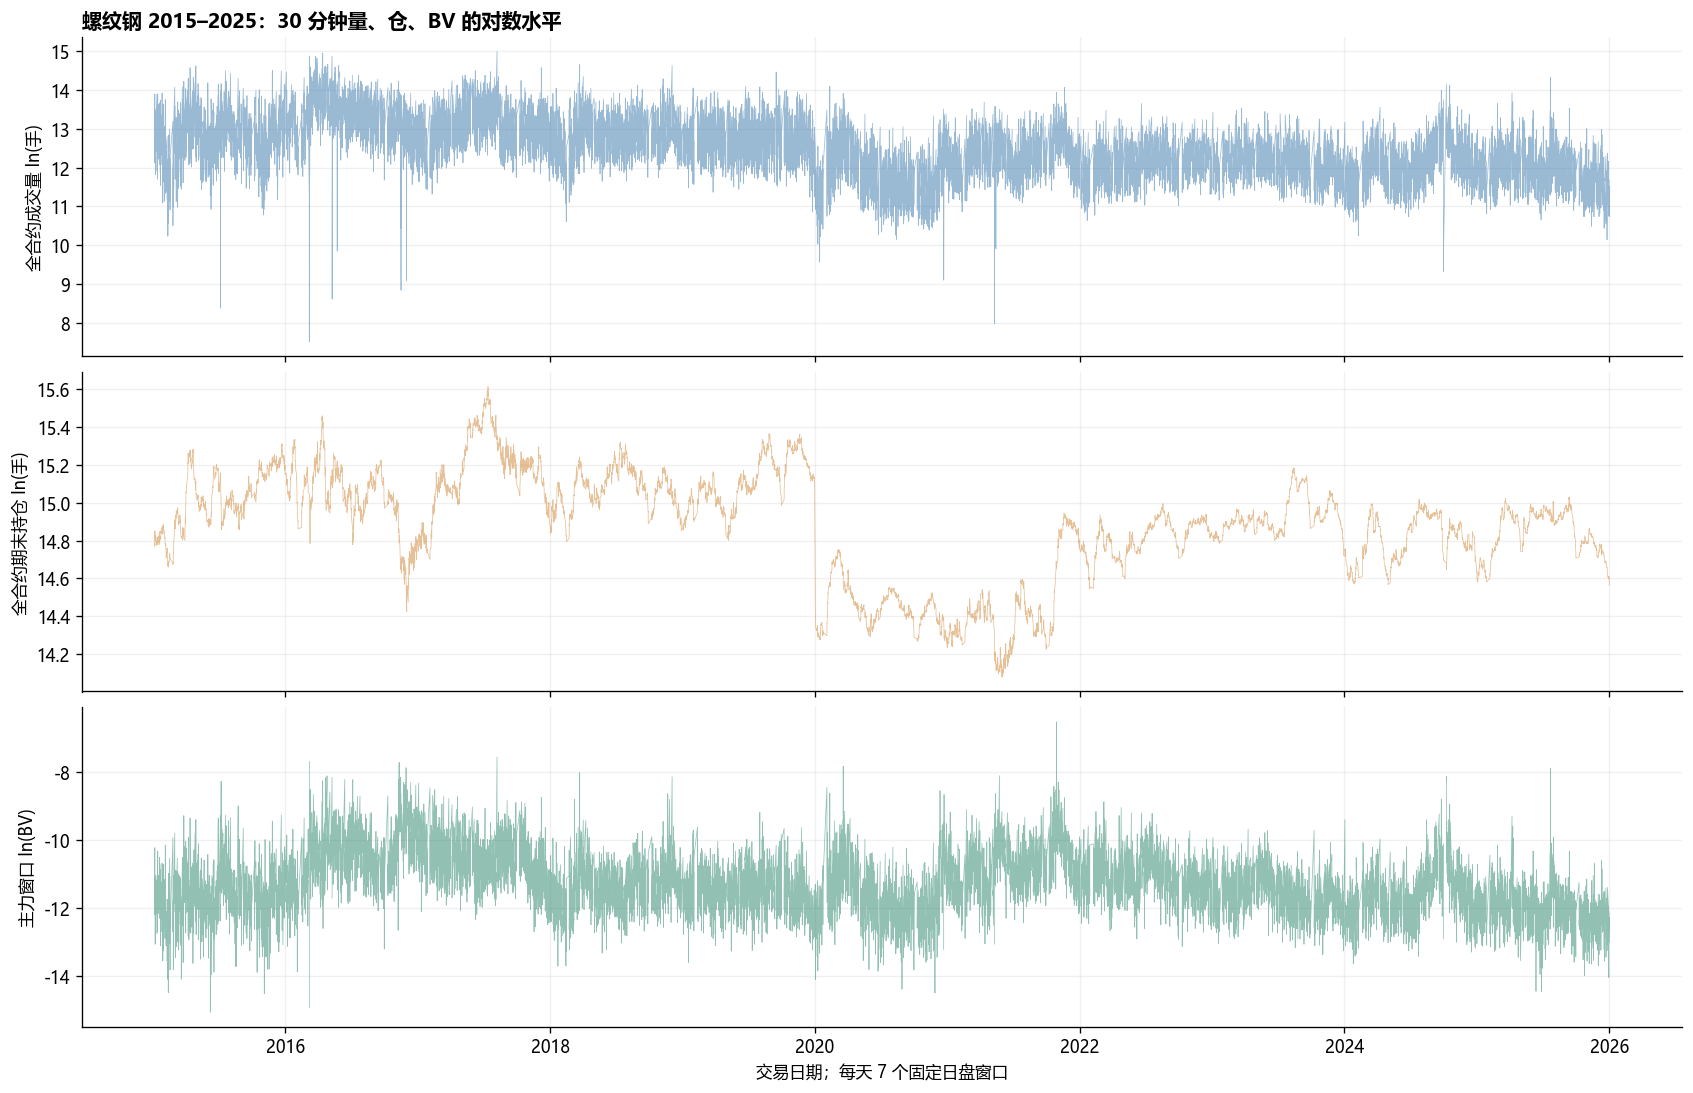

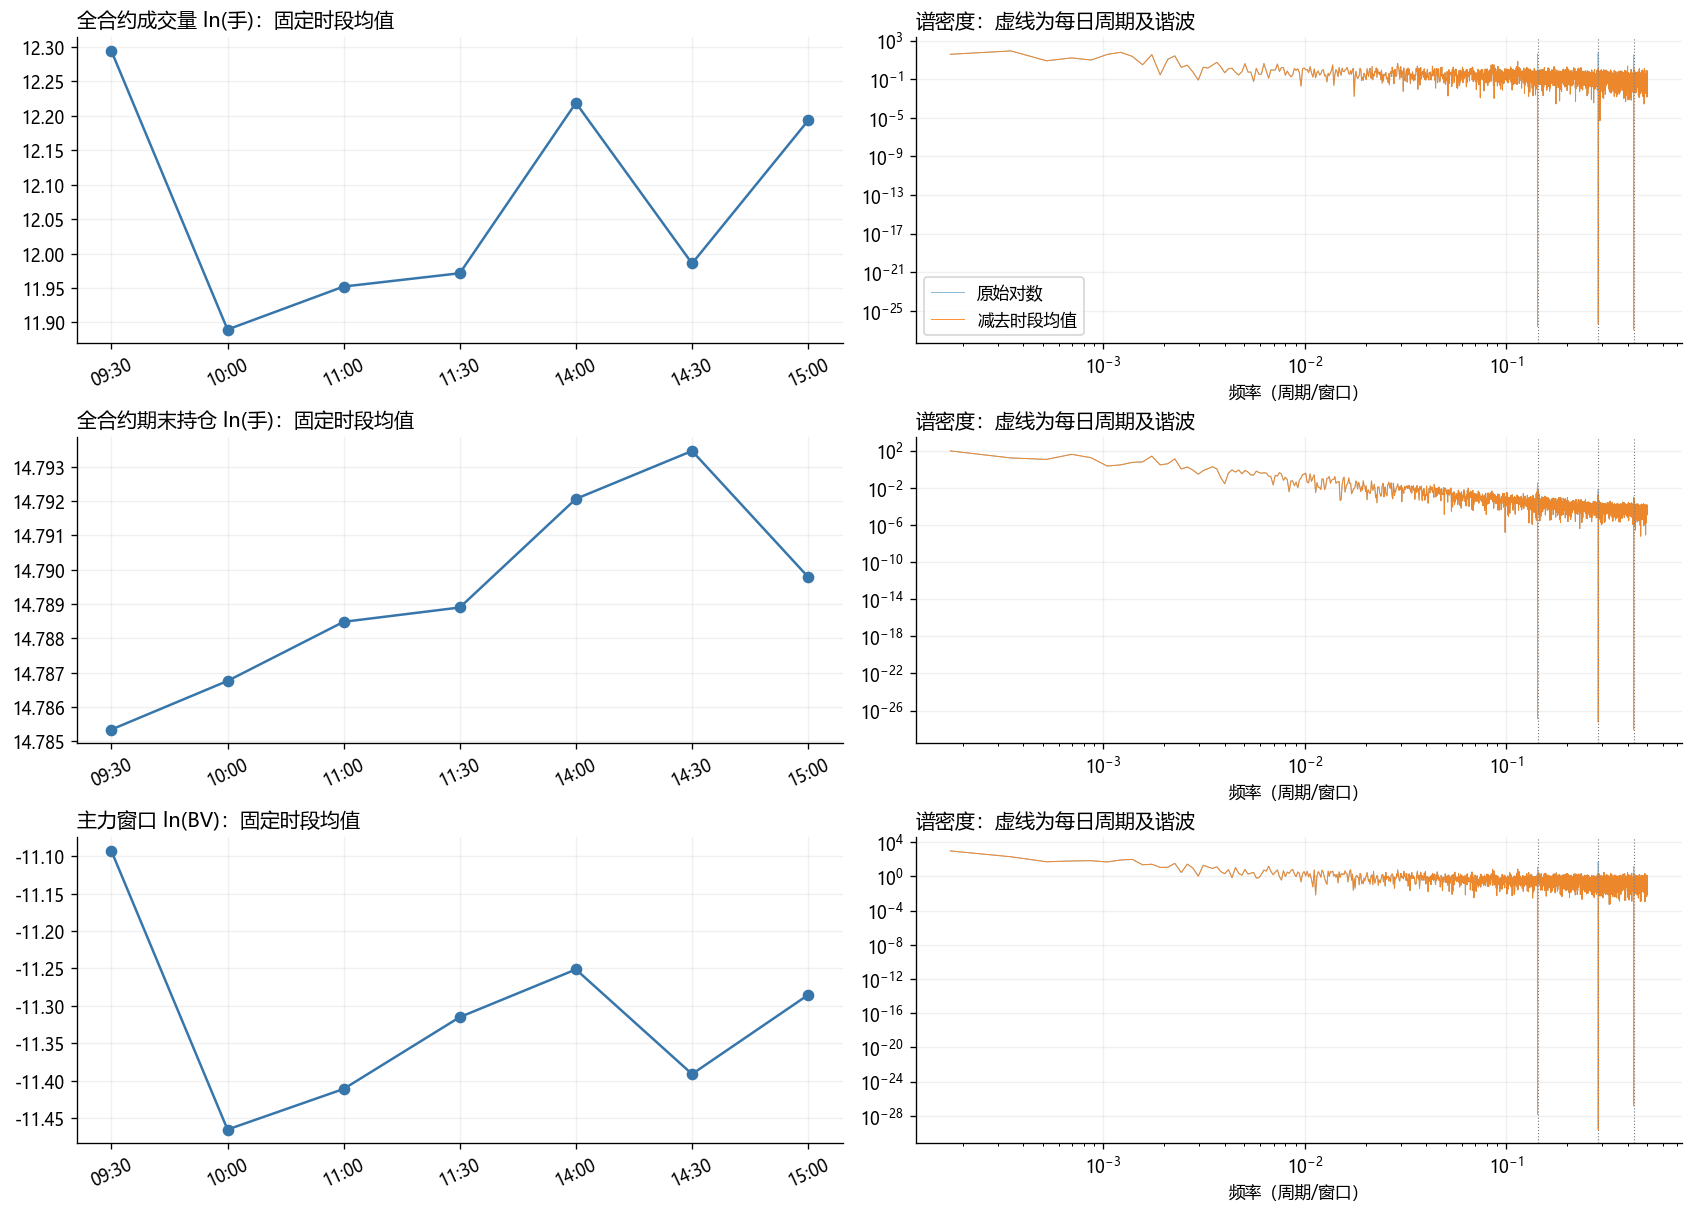

In [3]:
history_df = intraday_frames_by_width[30]
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)
for ax, column, color in zip(axes, LOG_COLUMNS, ["#3776ab", "#cf8230", "#27856b"]):
    ax.plot(history_df["window_end"], history_df[column], lw=0.45, alpha=0.5, color=color)
    ax.set_ylabel(VARIABLE_LABELS[column])
    ax.grid(alpha=0.18)
axes[0].set_title("螺纹钢 2015–2025：30 分钟量、仓、BV 的对数水平", loc="left", weight="bold")
axes[-1].set_xlabel("交易日期；每天 7 个固定日盘窗口")
if EXPORT_FILES:
    fig.savefig(output_dir / "testing_14_rb_log_levels.png", dpi=160)
plt.show()

primary_case = analysis_cases["30m_slot_longest"]
raw_log_df = primary_case["raw_log_df"]
slot_labels = primary_case["grid_df"]["slot"]
seasonal_log_df = primary_case["log_df"]
fig, axes = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)
for row, column in enumerate(LOG_COLUMNS):
    profile = raw_log_df[column].groupby(slot_labels).mean()
    axes[row, 0].plot(profile.index, profile.values, marker="o", color="#3776ab")
    axes[row, 0].set_title(VARIABLE_LABELS[column] + "：固定时段均值", loc="left")
    axes[row, 0].tick_params(axis="x", rotation=25)
    for series_df, label, alpha in [(raw_log_df, "原始对数", .5), (seasonal_log_df, "减去时段均值", .85)]:
        frequency, spectrum = periodogram(series_df[column].to_numpy(), detrend="constant")
        axes[row, 1].loglog(frequency[1:], spectrum[1:], lw=.6, alpha=alpha, label=label)
    for harmonic in [1, 2, 3]:
        axes[row, 1].axvline(harmonic / 7, color="grey", ls=":", lw=.7)
    axes[row, 1].set_title("谱密度：虚线为每日周期及谐波", loc="left")
    axes[row, 1].set_xlabel("频率（周期/窗口）")
    for ax in axes[row]: ax.grid(alpha=.18)
axes[0, 1].legend()
if EXPORT_FILES:
    fig.savefig(output_dir / "testing_14_rb_seasonality.png", dpi=160)
plt.show()

## 10. 普通协整的前提与条件检验

ADF/PP 的原假设是单位根，KPSS 的原假设是水平或趋势平稳；“ADF 未拒绝”不是单位根已获证明。ADF 同时检查常数、常数加趋势，以 BIC 在最多两个交易日窗口滞后中选择；KPSS 同时用自动带宽和五个交易日窗口带宽，保留分歧。KPSS 表中的 0.01/0.10 是表格边界，实际概率分别小于/大于边界。

以下保守门槛仅筛选 \(I(1)\) **候选**：水平 ADF 的 c/ct 都未拒绝，水平 KPSS-c 两种带宽均拒绝；一阶差分 ADF 拒绝且 KPSS-c 两种带宽均未拒绝。门槛通过不排除分数阶或断点，未通过也不是任何协整不存在的证明。

只对通过门槛的变量组合报告普通 EG、Phillips–Ouliaris Pz；若三列均通过，才显示 Johansen。多规格检验属于探索性，另列全表 Holm 调整概率，不能挑选单个显著值。

In [4]:
unit_root_rows = []
integration_rows = []
with threadpool_limits(limits=1):
    for case, case_info in analysis_cases.items():
        seasonal_period = case_info["slots_per_day"]
        for column in LOG_COLUMNS:
            series = case_info["log_df"][column].to_numpy()
            probabilities = {}
            for transformation, values in [("level", series), ("diff1", np.diff(series))]:
                trends = ["c", "ct"] if transformation == "level" else ["c"]
                for trend in trends:
                    adf = adfuller(values, maxlag=2 * seasonal_period, regression=trend, autolag="BIC")
                    probabilities[(transformation, "ADF", trend)] = adf[1]
                    unit_root_rows.append(dict(case=case, variable=column, transformation=transformation,
                        test="ADF", trend=trend, bandwidth="BIC", statistic=adf[0], pvalue=adf[1], lags=adf[2], p_bound=""))
                    for bandwidth in ["auto", 5 * seasonal_period]:
                        with warnings.catch_warnings(record=True) as caught:
                            warnings.simplefilter("always")
                            kp = kpss(values, regression=trend, nlags=bandwidth)
                        probabilities[(transformation, "KPSS", trend, str(bandwidth))] = kp[1]
                        unit_root_rows.append(dict(case=case, variable=column, transformation=transformation,
                            test="KPSS", trend=trend, bandwidth=str(bandwidth), statistic=kp[0],
                            pvalue=kp[1], lags=kp[2],
                            p_bound="<0.01" if kp[1] == .01 else (">0.10" if kp[1] == .1 else ""),
                            warning=" | ".join(str(w.message) for w in caught)))
                pp = PhillipsPerron(values, trend="c")
                unit_root_rows.append(dict(case=case, variable=column, transformation=transformation,
                    test="PP", trend="c", bandwidth="auto", statistic=pp.stat, pvalue=pp.pvalue, lags=pp.lags, p_bound=""))
            level_adf_not_reject = all(probabilities[("level", "ADF", t)] >= .05 for t in ["c", "ct"])
            level_kpss_reject = all(probabilities[("level", "KPSS", "c", str(b))] < .05 for b in ["auto", 5 * seasonal_period])
            difference_stationary_candidate = probabilities[("diff1", "ADF", "c")] < .05 and all(
                probabilities[("diff1", "KPSS", "c", str(b))] >= .05 for b in ["auto", 5 * seasonal_period])
            eligible = level_adf_not_reject and level_kpss_reject and difference_stationary_candidate
            integration_rows.append(dict(case=case, variable=column, i1_candidate=eligible,
                level_adf_c_p=probabilities[("level", "ADF", "c")],
                level_adf_ct_p=probabilities[("level", "ADF", "ct")],
                level_kpss_c_auto_p=probabilities[("level", "KPSS", "c", "auto")],
                level_kpss_c_fixed_p=probabilities[("level", "KPSS", "c", str(5 * seasonal_period))],
                diff_adf_c_p=probabilities[("diff1", "ADF", "c")],
                diff_kpss_c_auto_p=probabilities[("diff1", "KPSS", "c", "auto")],
                diff_kpss_c_fixed_p=probabilities[("diff1", "KPSS", "c", str(5 * seasonal_period))]))
        print(f"整数阶条件完成：{case}", flush=True)
unit_root_df = pd.DataFrame(unit_root_rows)
integration_summary_df = pd.DataFrame(integration_rows)
display(integration_summary_df.round(5))
print("全部 ADF / KPSS / PP 统计量、滞后和边界提示保存于 unit_root_df。")

classic_rows, classic_gate_rows, johansen_rows = [], [], []
with threadpool_limits(limits=1):
    for case, case_info in analysis_cases.items():
        candidate_flags = integration_summary_df.query("case == @case").set_index("variable")["i1_candidate"]
        combinations = list(itertools.combinations(LOG_COLUMNS, 2)) + [tuple(LOG_COLUMNS)]
        for variables in combinations:
            eligible = bool(candidate_flags.loc[list(variables)].all())
            classic_gate_rows.append(dict(case=case, variables=" + ".join(variables), eligible=eligible,
                reason="满足本研究 I(1) 候选门槛；仍需分数阶和结构稳定性检查" if eligible else "至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值"))
            if not eligible:
                continue
            # EG 逐一归一化，PO Pz 每个集合只做一次（Pz 对归一化不变）。
            for trend in ["c", "ct"]:
                for response in variables:
                    predictors = [v for v in variables if v != response]
                    eg = engle_granger(case_info["log_df"][response], case_info["log_df"][predictors],
                        trend=trend, max_lags=2 * case_info["slots_per_day"], method="bic")
                    classic_rows.append(dict(case=case, variables=" + ".join(variables),
                        normalization=response, trend=trend, test="EG", statistic=eg.stat, pvalue=eg.pvalue))
                po = phillips_ouliaris(case_info["log_df"][variables[0]], case_info["log_df"][list(variables[1:])],
                    trend=trend, test_type="Pz", kernel="bartlett")
                classic_rows.append(dict(case=case, variables=" + ".join(variables),
                    normalization="Pz invariant", trend=trend, test="PO-Pz", statistic=po.stat, pvalue=po.pvalue))
        if candidate_flags.all():
            selected_order = VAR(case_info["log_df"]).select_order(maxlags=2 * case_info["slots_per_day"]).selected_orders["bic"]
            level_var_order = max(1, int(selected_order))
            johansen = coint_johansen(case_info["log_df"], det_order=0, k_ar_diff=level_var_order - 1)
            for rank in range(3):
                johansen_rows.append(dict(case=case, level_var_order=level_var_order,
                    k_ar_diff=level_var_order - 1, null_rank_at_most=rank,
                    trace_stat=johansen.lr1[rank], critical_95=johansen.cvt[rank, 1],
                    reject_95=bool(johansen.lr1[rank] > johansen.cvt[rank, 1])))
classic_gate_df = pd.DataFrame(classic_gate_rows)
classic_df = pd.DataFrame(classic_rows)
johansen_df = pd.DataFrame(johansen_rows)
display(classic_gate_df)
if len(classic_df):
    classic_df["pvalue_holm_all_exploratory_tests"] = multipletests(classic_df["pvalue"], method="holm")[1]
    display(classic_df)
else:
    print("没有组合通过 I(1) 候选门槛；普通协整检验未执行，不能把此项跳过解释为已拒绝协整。")
if len(johansen_df):
    display(johansen_df)
    print("Johansen 使用 det_order=0 常数规格；满秩指向整个向量平稳，不应解释为非平凡 I(1) 协整。")
print(f"实际 EG/PO 检验数：{len(classic_df)}；Johansen 系统数：{johansen_df['case'].nunique() if len(johansen_df) else 0}")

整数阶条件完成：30m_raw_longest


整数阶条件完成：30m_slot_longest


整数阶条件完成：30m_slot_pre2020


整数阶条件完成：30m_slot_2020


整数阶条件完成：30m_slot_recent


...

整数阶条件完成：60m_slot_recent


,case,variable,i1_candidate,level_adf_c_p,level_adf_ct_p,level_kpss_c_auto_p,level_kpss_c_fixed_p,diff_adf_c_p,diff_kpss_c_auto_p,diff_kpss_c_fixed_p
0,30m_raw_longest,ln_total_volume,False,0.00000,0.00000,0.01000,0.0100,0.0,0.1,0.1
1,30m_raw_longest,ln_total_open_interest,False,0.02437,0.13601,0.01000,0.0100,0.0,0.1,0.1
2,30m_raw_longest,ln_bipower_variation,False,0.00000,0.00000,0.01000,0.0100,0.0,0.1,0.1
3,30m_slot_longest,ln_total_volume,False,0.00000,0.00000,0.01000,0.0100,0.0,0.1,0.1
4,30m_slot_longest,ln_total_open_interest,False,0.02695,0.15221,0.01000,0.0100,0.0,0.1,0.1
5,30m_slot_longest,ln_bipower_variation,False,0.00000,0.00000,0.01000,0.0100,0.0,0.1,0.1
6,30m_slot_pre2020,ln_total_volume,False,0.00000,0.00000,0.01000,0.0100,0.0,0.1,0.1
7,30m_slot_pre2020,ln_total_open_interest,False,0.00089,0.00772,0.02659,0.0148,0.0,0.1,0.1
8,30m_slot_pre2020,ln_bipower_variation,False,0.00000,0.00000,0.01000,0.0100,0.0,0.1,0.1
9,30m_slot_2020,ln_total_volume,False,0.00002,0.00000,0.01000,0.0100,0.0,0.1,0.1


全部 ADF / KPSS / PP 统计量、滞后和边界提示保存于 unit_root_df。


,case,variables,eligible,reason
0,30m_raw_longest,ln_total_volume + ln_total_open_interest,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
1,30m_raw_longest,ln_total_volume + ln_bipower_variation,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
2,30m_raw_longest,ln_total_open_interest + ln_bipower_variation,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
3,30m_raw_longest,ln_total_volume + ln_total_open_interest + ln_...,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
4,30m_slot_longest,ln_total_volume + ln_total_open_interest,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
5,30m_slot_longest,ln_total_volume + ln_bipower_variation,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
6,30m_slot_longest,ln_total_open_interest + ln_bipower_variation,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
7,30m_slot_longest,ln_total_volume + ln_total_open_interest + ln_...,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
8,30m_slot_pre2020,ln_total_volume + ln_total_open_interest,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值
9,30m_slot_pre2020,ln_total_volume + ln_bipower_variation,False,至少一列不满足 I(1) 候选门槛；不解释普通协整 p 值


没有组合通过 I(1) 候选门槛；普通协整检验未执行，不能把此项跳过解释为已拒绝协整。
实际 EG/PO 检验数：0；Johansen 系统数：0


## 11. 分数记忆阶：多带宽 GPH 与普通局部 Whittle

记忆阶 \(d\) 描述低频持续性。常见范围为：\(d<0.5\) 协方差平稳；\(0.5\le d<1\) 非平稳但具有均值回复性质；\(d=1\) 为整数单位根边界。趋势、断点、短期动态和有限样本都会影响估计，不能只根据一个估计值分类。

本节实现 GPH 对数周期图回归和**普通局部 Whittle（LW）**，并列显示水平 \(k=0\) 与先一阶差分、再加回 1 的 \(k=1\) 结果。LW 仅在过滤后 \(d-k\in(-0.5,0.5)\) 内优化；边界命中必须标记，不能把 0.49 或 0.51 当成功估计。GPH 也显示过滤后是否落在平稳范围。两分支分歧是需要更可靠估计的信号，不择优挑选。

带宽使用 \(m=\lfloor n^\delta\rfloor\)，\(\delta=0.50,0.55,0.60,0.65\)，并限制 \(m\le\lfloor n/(4S)\rfloor\)，\(S\) 为每天窗口数。该上限是本研究避开首个日周期峰的保守选择，不是通用最优规则。所有 \(d\) 都是探索性点估计，不为估计残差的记忆阶下降构造朴素 z 检验或显著性星号。

普通 LW 不等于非平稳 exact LW；未知均值/趋势时可使用 two-step ELW。[Shimotsu，2010](https://doi.org/10.1017/S0266466609100075)

,case,variable,k,gph_min,gph_median,gph_max,lw_min,lw_max,lw_boundary_count,gph_outside_count,bandwidth_count
0,30m_raw_longest,ln_total_volume,0,0.4738,0.5435,0.6625,0.4900,0.4900,4,2,4
1,30m_raw_longest,ln_total_volume,1,0.4761,0.5472,0.6512,0.5170,0.7392,0,2,4
2,30m_raw_longest,ln_total_open_interest,0,1.0393,1.0711,1.1132,0.4900,0.4900,4,4,4
3,30m_raw_longest,ln_total_open_interest,1,0.9272,1.0313,1.0568,1.0438,1.1259,0,0,4
4,30m_raw_longest,ln_bipower_variation,0,0.6195,0.6735,0.7902,0.4900,0.4900,4,4,4
5,30m_raw_longest,ln_bipower_variation,1,0.5536,0.5936,0.6782,0.5583,0.6628,0,0,4
6,30m_slot_longest,ln_total_volume,0,0.4738,0.5435,0.6625,0.4900,0.4900,4,2,4
7,30m_slot_longest,ln_total_volume,1,0.4573,0.5216,0.6149,0.5100,0.7355,1,2,4
8,30m_slot_longest,ln_total_open_interest,0,1.0393,1.0711,1.1132,0.4900,0.4900,4,4,4
9,30m_slot_longest,ln_total_open_interest,1,0.9274,1.0314,1.0571,1.0440,1.1264,0,0,4


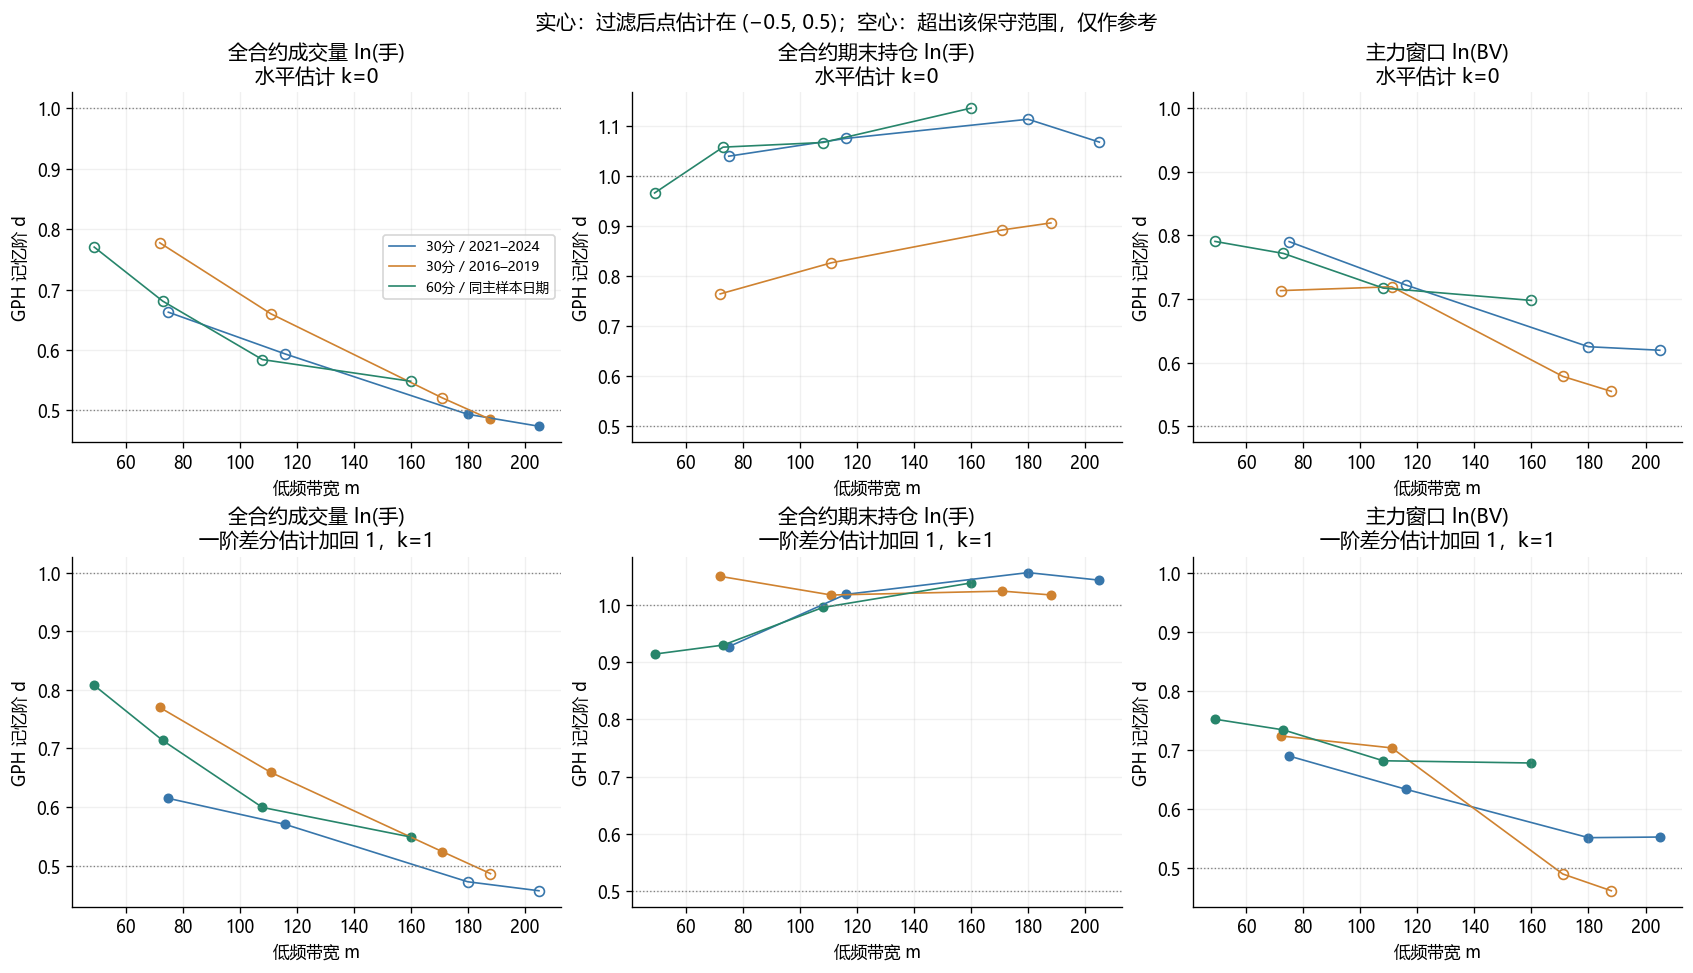

In [5]:
def fractional_memory(values, m, k=0):
    """低频记忆诊断；k 为预先做的整数差分阶，普通 LW 必须报告边界。"""
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or not np.isfinite(values).all() or k not in (0, 1):
        raise ValueError("需要连续有限一维序列，且 k 为 0 或 1。")
    filtered_values = np.diff(values) if k else values.copy()
    n = len(filtered_values)
    if not 10 <= m < n // 2 or np.std(filtered_values) == 0:
        raise ValueError("带宽或常量序列不适合记忆估计。")
    frequency = 2 * np.pi * np.arange(1, m + 1) / n
    spectrum = np.abs(np.fft.rfft(filtered_values - filtered_values.mean())[1:m + 1]) ** 2 / (2 * np.pi * n)
    if np.any(spectrum <= 0):
        raise ValueError("周期图存在非正值，不能取对数。")
    log_spectrum = np.log(spectrum)
    regressor = -2 * np.log(2 * np.sin(frequency / 2))
    gph_filtered_d = np.linalg.lstsq(np.column_stack([np.ones(m), regressor]), log_spectrum, rcond=None)[0][1]
    log_frequency = np.log(frequency)
    fit = minimize_scalar(
        lambda d: logsumexp(log_spectrum + 2 * d * log_frequency) - np.log(m) - 2 * d * log_frequency.mean(),
        bounds=(-.49, .49), method="bounded", options={"xatol": 1e-8})
    return dict(n=n, m=m, k=k, gph_d=k + float(gph_filtered_d),
        gph_filtered_in_stationary_range=bool(-.5 < gph_filtered_d < .5),
        lw_d=k + float(fit.x), lw_boundary=bool(abs(fit.x) > .485),
        lw_optimization_success=bool(fit.success))


def narrow_band_least_squares(response, regressors, m):
    """低频最小二乘，返回水平关系及共线性诊断，不提供未经校准的残差检验。"""
    response = np.asarray(response, dtype=float)
    regressors = np.asarray(regressors, dtype=float)
    if regressors.ndim == 1:
        regressors = regressors[:, None]
    if response.ndim != 1 or regressors.shape[0] != len(response) or not np.isfinite(response).all() or not np.isfinite(regressors).all():
        raise ValueError("NBLS 需要同网格连续有限序列。")
    if not regressors.shape[1] + 2 <= m < len(response) // 2:
        raise ValueError("NBLS 带宽无效。")
    scale = regressors.std(axis=0)
    if np.any(scale == 0):
        raise ValueError("NBLS 自变量存在常量。")
    regressors_fft = np.fft.rfft((regressors - regressors.mean(axis=0)) / scale, axis=0)[1:m + 1]
    response_fft = np.fft.rfft(response - response.mean())[1:m + 1]
    gram = np.real(regressors_fft.conj().T @ regressors_fft)
    condition_number = np.linalg.cond(gram)
    if not np.isfinite(condition_number) or condition_number > 1e10:
        raise ValueError("低频 Gram 矩阵过度共线。")
    slope = np.linalg.solve(gram, np.real(regressors_fft.conj().T @ response_fft)) / scale
    intercept = response.mean() - regressors.mean(axis=0) @ slope
    residual = response - intercept - regressors @ slope
    return dict(slope=slope, intercept=float(intercept), residual=residual,
        condition_number=float(condition_number), m=m)


def fractional_difference(values, d):
    """完整历史 Type-II 分数差分，样本前取零；不按权重阈值截断。"""
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or not np.isfinite(values).all() or not np.isfinite(d):
        raise ValueError("分数差分需要连续有限序列和有限 d。")
    weights = np.empty(len(values))
    weights[0] = 1.
    for lag in range(1, len(values)):
        weights[lag] = weights[lag - 1] * (lag - 1 - d) / lag
    return fftconvolve(values, weights, mode="full")[:len(values)]


# 数值恒等式只验证算法，不是实证协整证据。
numerical_values = np.random.default_rng(20261004).normal(size=128)
np.testing.assert_allclose(fractional_difference(numerical_values, 0), numerical_values, atol=1e-12)
np.testing.assert_allclose(fractional_difference(numerical_values, 1),
    np.r_[numerical_values[0], np.diff(numerical_values)], atol=1e-12)
np.testing.assert_allclose(fractional_difference(fractional_difference(numerical_values, -.3), .3),
    numerical_values, atol=1e-11)

bandwidths_by_case = {}
memory_rows = []
for case, case_info in analysis_cases.items():
    n, seasonal_period = len(case_info["log_df"]), case_info["slots_per_day"]
    bandwidths = sorted({min(int(n ** exponent), (n - 1) // (4 * seasonal_period)) for exponent in [.50, .55, .60, .65]})
    bandwidths = [m for m in bandwidths if m >= 10]
    bandwidths_by_case[case] = bandwidths
    for column in LOG_COLUMNS:
        for m in bandwidths:
            for k in [0, 1]:
                memory_rows.append(dict(case=case, variable=column,
                    **fractional_memory(case_info["log_df"][column], m, k)))
memory_df = pd.DataFrame(memory_rows)
memory_ranges_df = memory_df.groupby(["case", "variable", "k"], sort=False).agg(
    gph_min=("gph_d", "min"), gph_median=("gph_d", "median"), gph_max=("gph_d", "max"),
    lw_min=("lw_d", "min"), lw_max=("lw_d", "max"), lw_boundary_count=("lw_boundary", "sum"),
    gph_outside_count=("gph_filtered_in_stationary_range", lambda flags: int((~flags).sum())),
    bandwidth_count=("m", "size")).reset_index()
display(memory_ranges_df.round(4))
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for row, k in enumerate([0, 1]):
    for ax, column in zip(axes[row], LOG_COLUMNS):
        for case, color in [("30m_slot_longest", "#3776ab"), ("30m_slot_pre2020", "#cf8230"), ("60m_slot_same_dates", "#27856b")]:
            selected = memory_df.query("case == @case and variable == @column and k == @k")
            ax.plot(selected["m"], selected["gph_d"], lw=1, color=color, label=CASE_LABELS[case])
            inside = selected["gph_filtered_in_stationary_range"]
            ax.scatter(selected.loc[inside, "m"], selected.loc[inside, "gph_d"], color=color, s=25)
            ax.scatter(selected.loc[~inside, "m"], selected.loc[~inside, "gph_d"], facecolors="white", edgecolors=color, s=35)
        ax.axhline(.5, color="grey", ls=":", lw=.8)
        ax.axhline(1., color="grey", ls=":", lw=.8)
        branch = "水平估计 k=0" if k == 0 else "一阶差分估计加回 1，k=1"
        ax.set(title=VARIABLE_LABELS[column]+"\n"+branch, xlabel="低频带宽 m", ylabel="GPH 记忆阶 d")
        ax.grid(alpha=.18)
axes[0, 0].legend(fontsize=8)
fig.suptitle("实心：过滤后点估计在 (−0.5, 0.5)；空心：超出该保守范围，仅作参考", fontsize=12)
if EXPORT_FILES:
    fig.savefig(output_dir / "testing_14_rb_memory_orders.png", dpi=160)
plt.show()


## 12. 候选长期关系：在原对数水平上做 NBLS

对每个区间、每个带宽，拟合三变量关系的三种归一化，以及三个两变量关系。不同归一化不必产生互为倒数的系数。保留低频 Gram 条件数，防止将共线性造成的大系数误当经济关系。

核心观察是原变量与残差的记忆阶；reduction_vs_min 只是“输入变量中最低的估计 \(d\) 减去残差估计 \(d\)”的诊断数，**不是已识别的共同 \(d\)，也不是正式估计的协整强度 \(b\)**。不自动宣称同阶，不计算未经校准的显著性。

NBLS 是候选系数估计。短期冲击相关、内生性和残差参数估计会改变检验分布；普通残差 ADF 或把两个 \(d\) 的标准误直接相加都不足以解决问题。[半参数分数协整检验比较](https://www.statistik.uni-hannover.de/fileadmin/statistik/Working_Papers/A_Comparison_of_Semiparametric_Tests_for_Fractional_Cointegration.pdf)、[Nielsen–Frederiksen 的 fully modified NBLS](https://pure.au.dk/ws/files/21580778/rp10_31.pdf)

当任一输入或残差的过滤后 GPH 点估计不在 (−0.5, 0.5) 时，比较列留空；原始诊断保存在 raw_reduction 字段，图中为灰色叉号。范围内也只是点估计符合保守条件，不表示模型条件已被证明。

,case,relation,residual_d0_min,residual_d0_max,reduction0_min,reduction0_max,residual_d1_min,residual_d1_max,reduction1_min,reduction1_max,max_input_d_spread,max_gram_condition,comparable_m_k0,comparable_m_k1
0,30m_raw_longest,BV ~ V + OI,0.4449,0.6678,NaN,NaN,0.4640,0.6723,-0.0211,0.0010,0.6195,3.1783,0,2
1,30m_raw_longest,V ~ OI + BV,0.4165,0.6522,NaN,NaN,0.4783,0.7040,-0.0527,-0.0517,0.6195,2.7622,0,2
2,30m_raw_longest,OI ~ V + BV,0.7101,0.8537,NaN,NaN,0.6753,0.8519,-0.2006,-0.1815,0.6195,7.3684,0,2
3,30m_raw_longest,BV ~ V,0.4918,0.6907,NaN,NaN,0.4729,0.6706,-0.0256,-0.0193,0.1456,1.0000,0,2
4,30m_raw_longest,BV ~ OI,0.6079,0.7386,NaN,NaN,0.5844,0.6889,-0.0316,-0.0107,0.4881,1.0000,0,4
5,30m_raw_longest,V ~ OI,0.4740,0.6626,NaN,NaN,0.4765,0.6514,-0.0004,-0.0001,0.6195,1.0000,0,2
6,30m_slot_longest,BV ~ V + OI,0.4449,0.6678,NaN,NaN,0.4673,0.6754,-0.0605,-0.0247,0.6195,2.8834,0,2
7,30m_slot_longest,V ~ OI + BV,0.4165,0.6522,NaN,NaN,0.4726,0.6958,-0.0809,-0.0765,0.6195,2.7269,0,2
8,30m_slot_longest,OI ~ V + BV,0.7101,0.8537,NaN,NaN,0.6756,0.8531,-0.2382,-0.2128,0.6195,7.1674,0,2
9,30m_slot_longest,BV ~ V,0.4918,0.6907,NaN,NaN,0.4765,0.6733,-0.0586,-0.0583,0.1456,1.0000,0,2


全部系数、两个记忆分支和边界标记保存在 nbls_df；不按最佳带宽筛选结果。


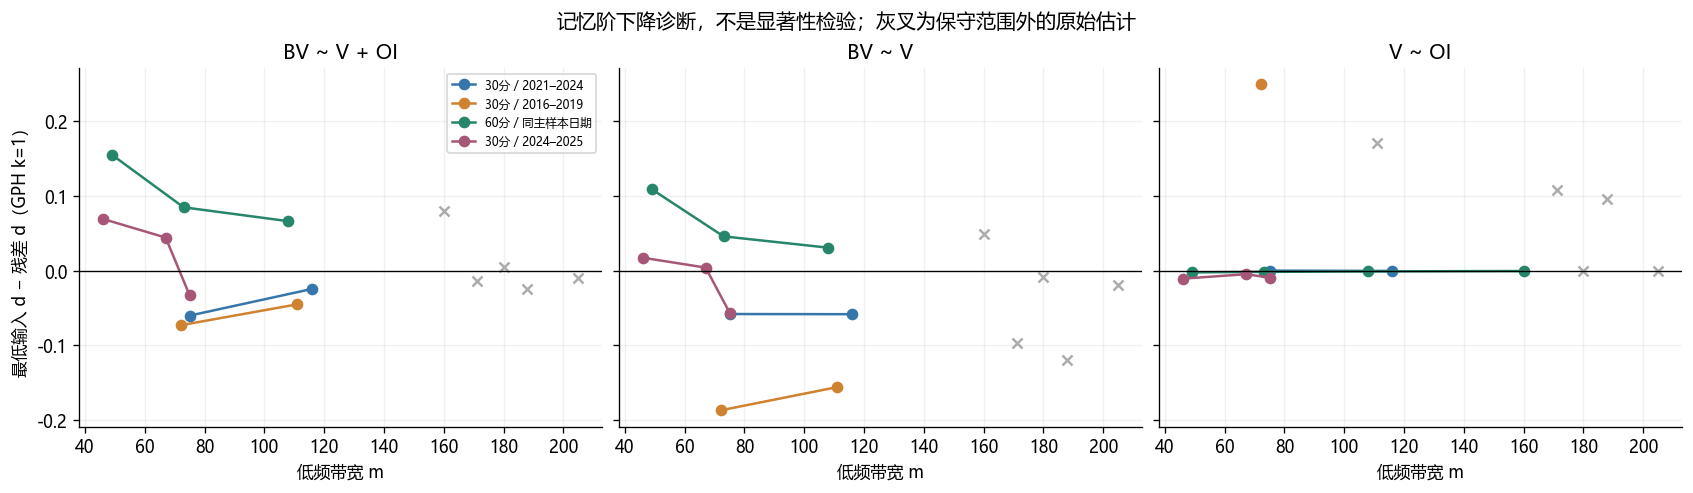

In [6]:
RELATIONS = [
    ("BV ~ V + OI", LOG_COLUMNS[2], LOG_COLUMNS[:2]),
    ("V ~ OI + BV", LOG_COLUMNS[0], LOG_COLUMNS[1:]),
    ("OI ~ V + BV", LOG_COLUMNS[1], [LOG_COLUMNS[0], LOG_COLUMNS[2]]),
    ("BV ~ V", LOG_COLUMNS[2], [LOG_COLUMNS[0]]),
    ("BV ~ OI", LOG_COLUMNS[2], [LOG_COLUMNS[1]]),
    ("V ~ OI", LOG_COLUMNS[0], [LOG_COLUMNS[1]]),
]
nbls_rows, nbls_fits = [], {}
for case, case_info in analysis_cases.items():
    log_df = case_info["log_df"]
    for relation, response, predictors in RELATIONS:
        for m in bandwidths_by_case[case]:
            fitted = narrow_band_least_squares(log_df[response], log_df[predictors], m)
            nbls_fits[(case, relation, m)] = fitted
            row = dict(case=case, relation=relation, m=m, intercept=fitted["intercept"],
                gram_condition=fitted["condition_number"])
            for predictor, slope in zip(predictors, fitted["slope"]):
                row[f"beta_{predictor}"] = slope
            for k in [0, 1]:
                input_ds = memory_df.loc[
                    memory_df["case"].eq(case) & memory_df["variable"].isin([response] + predictors)
                    & memory_df["m"].eq(m) & memory_df["k"].eq(k), "gph_d"]
                residual_memory = fractional_memory(fitted["residual"], m, k)
                row[f"input_d_min_k{k}"] = input_ds.min()
                row[f"input_d_max_k{k}"] = input_ds.max()
                row[f"input_d_spread_k{k}"] = input_ds.max() - input_ds.min()
                row[f"residual_d_k{k}"] = residual_memory["gph_d"]
                input_inside = bool(memory_df.loc[
                    memory_df["case"].eq(case) & memory_df["variable"].isin([response] + predictors)
                    & memory_df["m"].eq(m) & memory_df["k"].eq(k), "gph_filtered_in_stationary_range"].all())
                residual_inside = residual_memory["gph_filtered_in_stationary_range"]
                row[f"input_all_inside_k{k}"] = input_inside
                row[f"residual_inside_k{k}"] = residual_inside
                row[f"raw_reduction_k{k}"] = input_ds.min() - residual_memory["gph_d"]
                row[f"reduction_vs_min_k{k}"] = row[f"raw_reduction_k{k}"] if input_inside and residual_inside else np.nan
                row[f"residual_lw_d_k{k}"] = residual_memory["lw_d"]
                row[f"residual_lw_boundary_k{k}"] = residual_memory["lw_boundary"]
            nbls_rows.append(row)
nbls_df = pd.DataFrame(nbls_rows)
nbls_summary_df = nbls_df.groupby(["case", "relation"], sort=False).agg(
    residual_d0_min=("residual_d_k0", "min"), residual_d0_max=("residual_d_k0", "max"),
    reduction0_min=("reduction_vs_min_k0", "min"), reduction0_max=("reduction_vs_min_k0", "max"),
    residual_d1_min=("residual_d_k1", "min"), residual_d1_max=("residual_d_k1", "max"),
    reduction1_min=("reduction_vs_min_k1", "min"), reduction1_max=("reduction_vs_min_k1", "max"),
    max_input_d_spread=("input_d_spread_k0", "max"),
    max_gram_condition=("gram_condition", "max"),
    comparable_m_k0=("reduction_vs_min_k0", "count"),
    comparable_m_k1=("reduction_vs_min_k1", "count")).reset_index()
display(nbls_summary_df.round(4))
print("全部系数、两个记忆分支和边界标记保存在 nbls_df；不按最佳带宽筛选结果。")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, constrained_layout=True)
for ax, relation in zip(axes, ["BV ~ V + OI", "BV ~ V", "V ~ OI"]):
    for case, color in [("30m_slot_longest", "#3776ab"), ("30m_slot_pre2020", "#cf8230"), ("60m_slot_same_dates", "#27856b"), ("30m_slot_recent", "#a65778")]:
        selected = nbls_df.query("case == @case and relation == @relation")
        ax.plot(selected["m"], selected["reduction_vs_min_k1"], marker="o", label=CASE_LABELS[case], color=color)
        outside = selected["reduction_vs_min_k1"].isna()
        ax.scatter(selected.loc[outside, "m"], selected.loc[outside, "raw_reduction_k1"], marker="x", color="grey", alpha=.65)
    ax.axhline(0, color="black", lw=.8)
    ax.set(title=relation, xlabel="低频带宽 m")
    ax.grid(alpha=.18)
axes[0].set_ylabel("最低输入 d − 残差 d（GPH k=1）")
axes[0].legend(fontsize=7)
fig.suptitle("记忆阶下降诊断，不是显著性检验；灰叉为保守范围外的原始估计", fontsize=12)
if EXPORT_FILES:
    fig.savefig(output_dir / "testing_14_rb_candidate_memory_reduction.png", dpi=160)
plt.show()

## 13. 时序留出：系数在后段还能降低记忆阶吗

每个选定区间按完整交易日分为前 70% 与后 30%。时段均值、截距和 NBLS 系数仅用训练段估计；测试段使用训练段时段均值与同一组系数，不在测试段重新定中心、重新拟合后再声称稳定。

测试段单独拟合的系数仅列为变化诊断，绝不替换训练系数产生测试残差。带宽用各段长度的 \(n^{0.6}\) 并遵守季节频率上限。记忆估计本身随样本长度波动，因此留出结果也是稳健性证据，不提供未经校准的协整 p 值。

频域记忆估计不反映常量均衡水平的漂移，因此同时展示测试残差均值、标准差，以及均值相对于训练残差标准差的比值；这些也是描述统计，不套用独立样本均值检验。

In [7]:
holdout_rows = []
for case in ["30m_slot_longest", "30m_slot_pre2020", "30m_slot_recent", "60m_slot_same_dates"]:
    case_info = analysis_cases[case]
    grid_df, raw_log_df = case_info["grid_df"], case_info["raw_log_df"]
    unique_days = grid_df["trading_date"].drop_duplicates().to_list()
    train_days = unique_days[:int(len(unique_days) * .7)]
    train_mask = grid_df["trading_date"].isin(train_days)
    train_slot_means_df = raw_log_df.loc[train_mask].groupby(grid_df.loc[train_mask, "slot"]).mean()
    adjusted_df = raw_log_df - train_slot_means_df.reindex(grid_df["slot"]).set_axis(raw_log_df.index)
    train_df, test_df = adjusted_df.loc[train_mask], adjusted_df.loc[~train_mask]
    seasonal_period = case_info["slots_per_day"]
    train_m = min(int(len(train_df) ** .6), (len(train_df) - 1) // (4 * seasonal_period))
    test_m = min(int(len(test_df) ** .6), (len(test_df) - 1) // (4 * seasonal_period))
    if min(train_m, test_m) < 10:
        continue
    for relation, response, predictors in RELATIONS:
        train_fit = narrow_band_least_squares(train_df[response], train_df[predictors], train_m)
        test_fit = narrow_band_least_squares(test_df[response], test_df[predictors], test_m)
        test_residual = test_df[response].to_numpy() - train_fit["intercept"] - test_df[predictors].to_numpy() @ train_fit["slope"]
        row = dict(case=case, relation=relation, train_n=len(train_df), test_n=len(test_df),
            test_start=str(grid_df.loc[~train_mask, "trading_date"].iloc[0]),
            train_m=train_m, test_m=test_m, train_intercept=train_fit["intercept"],
            train_gram_condition=train_fit["condition_number"],
            test_mean_residual=float(test_residual.mean()), test_residual_std=float(test_residual.std()),
            train_residual_std=float(train_fit["residual"].std()),
            test_mean_in_train_std=float(test_residual.mean() / train_fit["residual"].std()),
            test_to_train_std=float(test_residual.std() / train_fit["residual"].std()))
        for predictor, train_slope, test_slope in zip(predictors, train_fit["slope"], test_fit["slope"]):
            row[f"train_beta_{predictor}"] = train_slope
            row[f"test_refit_beta_{predictor}"] = test_slope
        for part, part_df, residual, m in [
            ("train", train_df, train_fit["residual"], train_m),
            ("test_fixed_beta", test_df, test_residual, test_m)]:
            for k in [0, 1]:
                input_estimates = [fractional_memory(part_df[v], m, k) for v in [response] + predictors]
                input_ds = [estimate["gph_d"] for estimate in input_estimates]
                residual_memory = fractional_memory(residual, m, k)
                row[f"{part}_d_k{k}"] = residual_memory["gph_d"]
                row[f"{part}_input_all_inside_k{k}"] = all(estimate["gph_filtered_in_stationary_range"] for estimate in input_estimates)
                row[f"{part}_residual_inside_k{k}"] = residual_memory["gph_filtered_in_stationary_range"]
                row[f"{part}_raw_reduction_k{k}"] = min(input_ds) - residual_memory["gph_d"]
                row[f"{part}_reduction_k{k}"] = row[f"{part}_raw_reduction_k{k}"] if (
                    row[f"{part}_input_all_inside_k{k}"] and row[f"{part}_residual_inside_k{k}"]) else np.nan
        holdout_rows.append(row)
holdout_df = pd.DataFrame(holdout_rows)
display(holdout_df[[
    "case", "relation", "test_start", "train_n", "test_n",
    "train_reduction_k0", "test_fixed_beta_reduction_k0",
    "train_reduction_k1", "test_fixed_beta_reduction_k1",
]].round(4))
display(holdout_df.loc[holdout_df["relation"].eq("BV ~ V + OI"),
    ["case", "train_beta_ln_total_volume", "test_refit_beta_ln_total_volume",
     "train_beta_ln_total_open_interest", "test_refit_beta_ln_total_open_interest",
     "test_mean_residual"]].round(4))
display(holdout_df[["case", "relation", "test_mean_residual", "train_residual_std",
    "test_residual_std", "test_mean_in_train_std", "test_to_train_std"]].round(4))


,case,relation,test_start,train_n,test_n,train_reduction_k0,test_fixed_beta_reduction_k0,train_reduction_k1,test_fixed_beta_reduction_k1
0,30m_slot_longest,BV ~ V + OI,2023-09-20,4018,1729,NaN,NaN,0.0084,NaN
1,30m_slot_longest,V ~ OI + BV,2023-09-20,4018,1729,NaN,NaN,NaN,NaN
2,30m_slot_longest,OI ~ V + BV,2023-09-20,4018,1729,NaN,NaN,-0.1305,NaN
3,30m_slot_longest,BV ~ V,2023-09-20,4018,1729,NaN,NaN,NaN,NaN
4,30m_slot_longest,BV ~ OI,2023-09-20,4018,1729,NaN,NaN,-0.0145,-0.0449
5,30m_slot_longest,V ~ OI,2023-09-20,4018,1729,NaN,NaN,-0.0001,NaN
6,30m_slot_pre2020,BV ~ V + OI,2019-01-28,3689,1582,NaN,NaN,NaN,NaN
7,30m_slot_pre2020,V ~ OI + BV,2019-01-28,3689,1582,NaN,NaN,NaN,NaN
8,30m_slot_pre2020,OI ~ V + BV,2019-01-28,3689,1582,NaN,NaN,NaN,NaN
9,30m_slot_pre2020,BV ~ V,2019-01-28,3689,1582,NaN,NaN,NaN,NaN


,case,train_beta_ln_total_volume,test_refit_beta_ln_total_volume,train_beta_ln_total_open_interest,test_refit_beta_ln_total_open_interest,test_mean_residual
0,30m_slot_longest,1.2647,1.1879,-1.1134,0.1488,-0.2665
6,30m_slot_pre2020,1.5618,1.2596,-1.7474,-0.3061,-0.1444
12,30m_slot_recent,1.3816,0.5462,-0.7738,0.2405,0.1161
18,60m_slot_same_dates,1.2790,1.1510,-1.0900,0.2283,-0.2693


,case,relation,test_mean_residual,train_residual_std,test_residual_std,test_mean_in_train_std,test_to_train_std
0,30m_slot_longest,BV ~ V + OI,-0.2665,0.5023,0.4738,-0.5306,0.9434
1,30m_slot_longest,V ~ OI + BV,-0.0183,0.3238,0.3504,-0.0564,1.0820
2,30m_slot_longest,OI ~ V + BV,-0.0381,0.2198,0.1971,-0.1734,0.8965
3,30m_slot_longest,BV ~ V,-0.3514,0.5703,0.4585,-0.6163,0.8039
4,30m_slot_longest,BV ~ OI,-0.5359,0.6486,0.7029,-0.8262,1.0839
5,30m_slot_longest,V ~ OI,-0.2130,0.4252,0.4998,-0.5009,1.1754
6,30m_slot_pre2020,BV ~ V + OI,-0.1444,0.6387,0.5446,-0.2260,0.8527
7,30m_slot_pre2020,V ~ OI + BV,-0.1290,0.3669,0.3754,-0.3516,1.0232
8,30m_slot_pre2020,OI ~ V + BV,0.0710,0.1951,0.2036,0.3640,1.0434
9,30m_slot_pre2020,BV ~ V,-0.3409,0.6346,0.4199,-0.5372,0.6616


## 14. 分数差分的用途与不能推出的结论

\((1-L)^d x_t=\sum_{j=0}^{t}w_jx_{t-j}\)，\(w_0=1,\;w_j=w_{j-1}(j-1-d)/j\)。使用样本内完整历史、样本前取零的 Type-II 初始化，不按小权重任意截断。下图仅说明分数差分如何改变持久性，不能用“变换后三列均平稳”证明原水平协整。

示例 \(d\) 来自主区间 GPH 多带宽中位数：水平估计超过 0.5 时使用一阶差分分支加回 1；该选择是滤波演示，不替代 two-step ELW。固定舍弃最初 250 个交易日的滤波结果以减轻初始化影响，再比较 ACF。没有挑选参数优化 p 值。

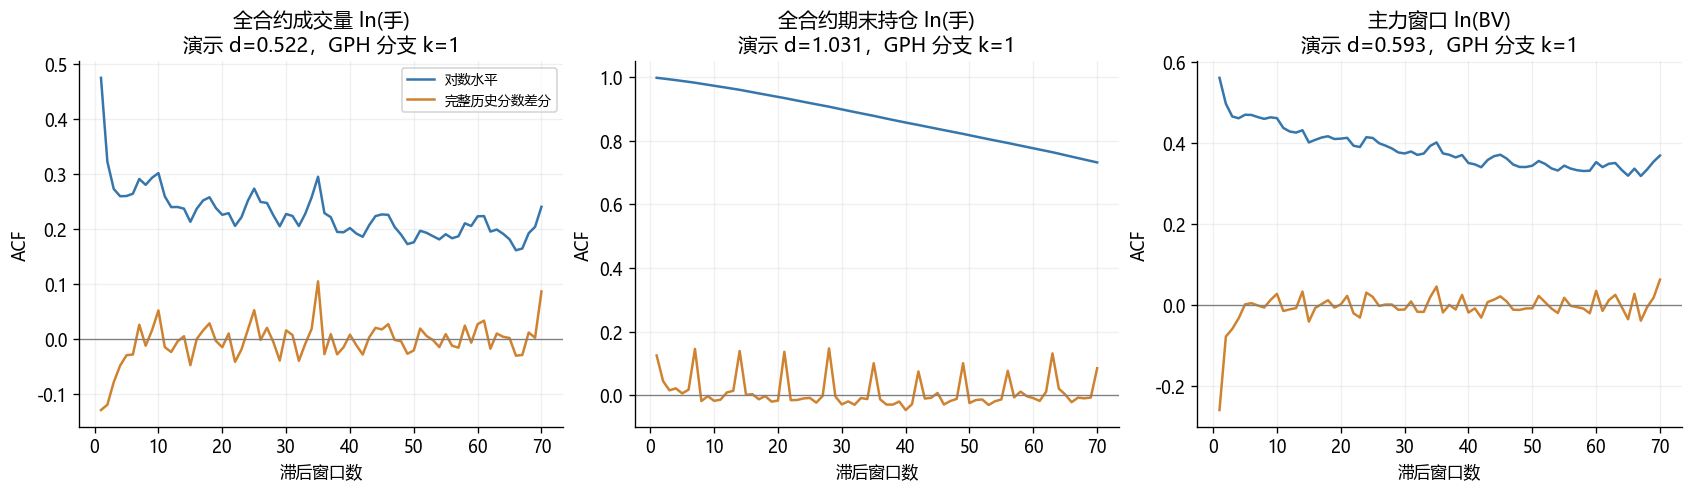

,variable,chosen_d,gph_branch,burn_in_windows,raw_acf_1,filtered_acf_1,raw_acf_daily,filtered_acf_daily
0,ln_total_volume,0.5216,1,1750,0.4755,-0.1298,0.2913,0.0257
1,ln_total_open_interest,1.0314,1,1750,0.9982,0.1250,0.9828,0.1457
2,ln_bipower_variation,0.5933,1,1750,0.5604,-0.2589,0.4636,-0.0010


In [8]:
fractional_filter_rows = []
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
case = "30m_slot_longest"
case_info = analysis_cases[case]
seasonal_period = case_info["slots_per_day"]
burn_in = 250 * seasonal_period
for ax, column in zip(axes, LOG_COLUMNS):
    estimates = memory_df.loc[memory_df["case"].eq(case) & memory_df["variable"].eq(column)]
    level_d = estimates.loc[estimates["k"].eq(0), "gph_d"].median()
    k = int(level_d > .5)
    chosen_d = estimates.loc[estimates["k"].eq(k), "gph_d"].median()
    if not 0 <= chosen_d < 1.5:
        ax.set_title(VARIABLE_LABELS[column] + "：估计超出演示范围，跳过")
        continue
    centered_values = case_info["log_df"][column].to_numpy()
    centered_values = centered_values - centered_values.mean()
    filtered_values = fractional_difference(centered_values, chosen_d)
    raw_acf = acf(centered_values[burn_in:], nlags=10 * seasonal_period, fft=True)
    filtered_acf = acf(filtered_values[burn_in:], nlags=10 * seasonal_period, fft=True)
    ax.plot(np.arange(1, len(raw_acf)), raw_acf[1:], label="对数水平", color="#3776ab")
    ax.plot(np.arange(1, len(filtered_acf)), filtered_acf[1:], label="完整历史分数差分", color="#cf8230")
    ax.axhline(0, color="grey", lw=.8)
    ax.set(title=f"{VARIABLE_LABELS[column]}\n演示 d={chosen_d:.3f}，GPH 分支 k={k}", xlabel="滞后窗口数", ylabel="ACF")
    ax.grid(alpha=.18)
    fractional_filter_rows.append(dict(variable=column, chosen_d=chosen_d, gph_branch=k, burn_in_windows=burn_in,
        raw_acf_1=raw_acf[1], filtered_acf_1=filtered_acf[1],
        raw_acf_daily=raw_acf[seasonal_period], filtered_acf_daily=filtered_acf[seasonal_period]))
axes[0].legend(fontsize=8)
if EXPORT_FILES:
    fig.savefig(output_dir / "testing_14_rb_fractional_difference_acf.png", dpi=160)
plt.show()
fractional_filter_df = pd.DataFrame(fractional_filter_rows)
display(fractional_filter_df.round(4))

## 15. 文献中的进一步方法与当前结论边界

第 8–14 节执行单位根/平稳性条件诊断、多带宽 GPH 与普通 LW、NBLS 候选关系、窗口和时期敏感性、训练系数固定的时序留出、完整历史分数差分。这些环节属于实证筛查。第 17–22 节补充两阶段可行 ELW、CH06 检验及有限样本校准，最终结论见第 22 节。

| 方法 | 能进一步回答的问题 | 当前实施状态 |
|---|---|---|
| Two-step exact local Whittle | 未知均值/趋势下非平稳 d 的可靠估计 | 已按作者 2010 算法在 Python 实现并验证，见第 17–20 节 |
| Fully modified NBLS | 校正内生性或相关短期冲击并作推断 | 未执行；普通 NBLS 不替代它 |
| Chen–Hurvich 半参数检验 | 共同记忆阶条件下检验分数协整 | 已执行，并补充模拟与条件 bootstrap 校准，见第 18–22 节 |
| FCVAR | 联合估计 d、b、beta 和协整秩 | 未执行；须检查共同阶、动态和残差 |
| 周期分数阶协整 | 在非零日周期频率检验共同随机周期 | 未执行；时段去均值不能替代 |
| 断点稳健记忆检验 | 避免未知水平断点被误识别为长记忆 | 未执行；分时期对比只是敏感性检查 |

主要阅读来源：

- Hualde & Nielsen (2022), [Fractional integration and cointegration](https://arxiv.org/abs/2211.10235)。
- Shimotsu (2010), [Exact local Whittle estimation with unknown mean and time trend](https://doi.org/10.1017/S0266466609100075)；[R ELW2S 文档](https://search.r-project.org/CRAN/refmans/LongMemoryTS/html/ELW2S.html)。
- Johansen & Nielsen (2012), [Likelihood inference for a fractionally cointegrated VAR](https://doi.org/10.3982/ECTA9299)；[作者软件](https://sites.google.com/view/mortennielsen/software)。
- Voges & Sibbertsen (2021), [Cyclical fractional cointegration](https://doi.org/10.1016/j.ecosta.2020.05.004)：与日内量和波动的周期关系直接相关。
- Leschinski, Voges & Sibbertsen (2021), [A comparison of semiparametric tests for fractional cointegration](https://www.statistik.uni-hannover.de/fileadmin/statistik/Working_Papers/A_Comparison_of_Semiparametric_Tests_for_Fractional_Cointegration.pdf)。
- Nielsen & Frederiksen (2011；链接为 2010 年公开稿), [Fully modified narrow-band least squares estimation](https://pure.au.dk/ws/files/21580778/rp10_31.pdf)。
- Iacone, Nielsen & Taylor (2022), [记忆检验与未知水平断点](https://pure.au.dk/ws/files/210948318/rp21_04.pdf)。

未调用 R 的 ELW2S 或 FCVAR 包；Python 实现与原论文、作者 MATLAB 算法及模拟真值核对。即便筛查未发现稳定关系，也不能排除其他品种、频率、时期或季节频率上的关系。正式推断还需处理零 BV、数据源完整合约覆盖和潜在结构变化。

In [9]:
research_results = {
    "configuration": {
        "underlying": UNDERLYING_CODE if "UNDERLYING_CODE" in globals() else "RB",
        "start": "2015-01-01", "end": "2025-12-31", "roll_trigger_ratio": 1.0,
        "primary_width_minutes": 30, "robustness_width_minutes": 60,
        "ordinary_cointegration_interpretation": "Only conditional on I(1) candidate gate",
        "fractional_interpretation": "Exploratory memory reduction; no formal fractional cointegration p-value",
    },
}
for name, table_df in {
    "sample_summary": sample_summary_df, "zero_bv_windows": zero_bv_audit_df,
    "unit_root_tests": unit_root_df, "integration_gate": integration_summary_df,
    "classic_gate": classic_gate_df, "classic_tests": classic_df, "johansen": johansen_df,
    "memory_estimates": memory_df, "memory_ranges": memory_ranges_df,
    "nbls": nbls_df, "nbls_summary": nbls_summary_df,
    "holdout": holdout_df, "fractional_difference": fractional_filter_df,
}.items():
    research_results[name] = json.loads(table_df.to_json(orient="records", date_format="iso", force_ascii=False))
research_results_path = output_dir / "testing_14_rb_cointegration_results.json"
if EXPORT_FILES:
    research_results_path.write_text(json.dumps(research_results, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
    assert json.loads(research_results_path.read_text(encoding="utf-8")) == research_results
    print(f"已保存并复读核对：{research_results_path.name}")
print(f"研究规格 {len(analysis_cases)}；记忆阶估计 {len(memory_df)}；NBLS 候选拟合 {len(nbls_df)}；时序留出关系 {len(holdout_df)}。")
print("NBLS 拟合数是探索次数，不是相互独立的显著性检验数。")


研究规格 8；记忆阶估计 174；NBLS 候选拟合 174；时序留出关系 24。
NBLS 拟合数是探索次数，不是相互独立的显著性检验数。


## 16. 探索分析摘要（正式检验与最终结论见第 17–22 节）

以下结论由本 Notebook 的表直接生成。记忆阶的中位数和范围都是带宽敏感性描述，不是置信区间。主样本是连续正值区间，不代表 2015—2025 年全历史已经完成无条件协整检验。


In [10]:
primary_sample = sample_summary_df.set_index("case").loc["30m_slot_longest"]
primary_memory_df = memory_ranges_df.loc[
    memory_ranges_df["case"].eq("30m_slot_longest") & memory_ranges_df["k"].eq(1),
    ["variable", "gph_min", "gph_median", "gph_max", "gph_outside_count", "bandwidth_count"],
].copy()
primary_memory_df["variable"] = primary_memory_df["variable"].map(VARIABLE_LABELS)
primary_relation_df = nbls_df.loc[nbls_df["case"].eq("30m_slot_longest") & nbls_df["relation"].eq("BV ~ V + OI")]
primary_holdout = holdout_df.loc[holdout_df["case"].eq("30m_slot_longest") & holdout_df["relation"].eq("BV ~ V + OI")].iloc[0]
recent_relation_df = nbls_df.loc[nbls_df["case"].eq("30m_slot_recent") & nbls_df["relation"].eq("BV ~ V + OI")]
display(Markdown(f"""
**尚无足够证据确认全合约量、仓与主力 BV 存在跨时期稳定的三变量协整关系。**

- 数据覆盖 2015—2025 年。30 分钟主检验实际使用 {primary_sample['actual_start']} 至 {primary_sample['actual_end']}，{int(primary_sample['selected_days'])} 个完整交易日、{int(primary_sample['selected_windows']):,} 个窗口；零 BV 日将对数样本分成多段，另列前期、2020 年、近期与 60 分钟敏感性结果。
- 普通协整：{len(classic_gate_df)} 个候选变量组合中，{int(classic_gate_df['eligible'].sum())} 个通过本研究的 I(1) 候选门槛。成交量/BV 的 ADF 与 KPSS 存在冲突，不能写成已确认 I(0)，也不能直接解释 EG/Johansen 的拒绝结果。
- 分数记忆：主样本持仓记忆阶的点估计接近 1，量和 BV 更接近 0.5–0.7；这些是描述性点估计比较，**未检验阶数差异的统计显著性**。三列共同阶不能直接假定。下表用差分分支加回 1 展示，成交量部分带宽超出保守估计范围，已标记。
- 主样本 BV ~ V + OI 的原始 k=1 降阶诊断范围为 {primary_relation_df['raw_reduction_k1'].min():.3f} 至 {primary_relation_df['raw_reduction_k1'].max():.3f}；其中 {primary_relation_df['reduction_vs_min_k1'].count()} / {len(primary_relation_df)} 个带宽通过点估计范围筛查。没有显示稳定的共同降阶。
- 时序稳定性：该关系的持仓系数在训练段为 {primary_holdout['train_beta_ln_total_open_interest']:.3f}，测试段单独估计为 {primary_holdout['test_refit_beta_ln_total_open_interest']:.3f}。后者只用于稳定性诊断，未用于测试残差。这种变化不支持把一个全期系数当成可靠均衡关系。
- 2024—2025 年出现候选降阶，但 30 分钟原水平分支与差分分支不一致：原始诊断范围分别为 {recent_relation_df['raw_reduction_k0'].min():.3f}～{recent_relation_df['raw_reduction_k0'].max():.3f}、{recent_relation_df['raw_reduction_k1'].min():.3f}～{recent_relation_df['raw_reduction_k1'].max():.3f}。该时期可供后续正式方法确认，不能反推所有历史时期都协整。

第 17–22 节使用两阶段可行 ELW、CH06 和有限样本校准进一步检查这些候选关系；本节仅汇总探索分析，最终结论见第 22 节。当前结果不证明协整绝不存在，也不构成可交易或可预测的结论。
"""))
display(primary_memory_df.round(4))



**尚无足够证据确认全合约量、仓与主力 BV 存在跨时期稳定的三变量协整关系。**

- 数据覆盖 2015—2025 年。30 分钟主检验实际使用 2021-05-17 至 2024-09-27，821 个完整交易日、5,747 个窗口；零 BV 日将对数样本分成多段，另列前期、2020 年、近期与 60 分钟敏感性结果。
- 普通协整：32 个候选变量组合中，0 个通过本研究的 I(1) 候选门槛。成交量/BV 的 ADF 与 KPSS 存在冲突，不能写成已确认 I(0)，也不能直接解释 EG/Johansen 的拒绝结果。
- 分数记忆：主样本持仓记忆阶的点估计接近 1，量和 BV 更接近 0.5–0.7；这些是描述性点估计比较，**未检验阶数差异的统计显著性**。三列共同阶不能直接假定。下表用差分分支加回 1 展示，成交量部分带宽超出保守估计范围，已标记。
- 主样本 BV ~ V + OI 的原始 k=1 降阶诊断范围为 -0.060 至 0.005；其中 2 / 4 个带宽通过点估计范围筛查。没有显示稳定的共同降阶。
- 时序稳定性：该关系的持仓系数在训练段为 -1.113，测试段单独估计为 0.149。后者只用于稳定性诊断，未用于测试残差。这种变化不支持把一个全期系数当成可靠均衡关系。
- 2024—2025 年出现候选降阶，但 30 分钟原水平分支与差分分支不一致：原始诊断范围分别为 0.212～0.280、-0.033～0.069。该时期可供后续正式方法确认，不能反推所有历史时期都协整。

第 17–22 节使用两阶段可行 ELW、CH06 和有限样本校准进一步检查这些候选关系；本节仅汇总探索分析，最终结论见第 22 节。当前结果不证明协整绝不存在，也不构成可交易或可预测的结论。


,variable,gph_min,gph_median,gph_max,gph_outside_count,bandwidth_count
7,全合约成交量 ln(手),0.4573,0.5216,0.6149,2,4
9,全合约期末持仓 ln(手),0.9274,1.0314,1.0571,0,4
11,主力窗口 ln(BV),0.5519,0.5933,0.6899,0,4


## 17. 两阶段可行 ELW 与正式分数协整检验

本节补充前述探索分析，继续使用同一组固定窗口和连续正值区间，不修改主力规则或零值处理。先用两阶段可行 exact local Whittle（ELW）重新估计各列的记忆阶，再用 Chen–Hurvich 的分数协整检验考察成交量与 BV。正式检验的概率仍以模型条件为前提，不能脱离共同阶、无结构变化和低频谱条件解释。

**ELW 实现依据。** 按 [Shimotsu (2010)](https://doi.org/10.1017/S0266466609100075) 的目标函数及[作者 2010 年 MATLAB 软件](https://sites.google.com/view/katsumishimotsu/software)实现，第一阶段为三阶 Kolmogorov taper 的局部 Whittle；第二阶段以其结果为起点优化完整历史分数差分的 ELW 目标。均值权重在 d≤0.5 为 1，在 d≥0.75 为 0，中间用余弦过渡；保留全部样本，不删除第一条观测。线性趋势规格在两个阶段之前真正去除趋势。优化器采用 SciPy，结果不声称与 MATLAB 浮点输出逐位相同。

只读核对的作者软件 elwcode10.zip 的 SHA256 为 adb3e59fbd4fc3f76993162b02b462459c430ad859f40612e547d3ac54f743cf。另核对 LongMemoryTS 0.1.0 的 ELW_est.R，发现其去趋势结果未传入优化、余弦权重未作区间限制；本节不照搬这段实现。原包源码 SHA256 为 f0666f4e0cb77814eab9e8606ff969429d7497ba17bf83a49f49b48c2f64b098。

ELW 的标准误 \(1/(2\sqrt m)\) 仅对各原始序列给出模型条件下的近似区间。区间重叠不证明同阶；不将两个估计的标准误当成独立量相加，也不将该标准误用于估计残差的降阶检验。第一阶段的 m 调整为不超过指定带宽的 3 的倍数，以保证 taper 目标函数归一化一致。

In [11]:
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.signal import lfilter
from scipy.special import gammaln
import time

def exact_whittle_objective(d, values, m):
    """Shimotsu 可行 ELW：未知均值的分段权重，完整历史 Type-II 分数差分。"""
    values = np.asarray(values, dtype=float)
    d = float(np.asarray(d).reshape(-1)[0])
    if d <= .5:
        weight = 1.
    elif d >= .75:
        weight = 0.
    else:
        weight = .5 * (1 + np.cos(4 * np.pi * d))
    centered_values = values - weight * values.mean() - (1 - weight) * values[0]
    n = len(values)
    weights = np.r_[1., np.cumprod((np.arange(1, n) - 1. - d) / np.arange(1, n))]
    differenced_values = fftconvolve(centered_values, weights, mode="full")[:n]
    powers = np.abs(np.fft.rfft(differenced_values)[1:m + 1]) ** 2 / (2 * np.pi * n)
    if not np.isfinite(powers).all() or powers.mean() <= 0:
        return 1e100
    log_frequencies = np.log(2 * np.pi * np.arange(1, m + 1) / n)
    return float(np.log(powers.mean()) - 2 * d * log_frequencies.mean())


def feasible_elw(values, m, trend_order=0):
    """作者 2010 两阶段思想；SciPy 局部优化，保留收敛、边界及梯度诊断。"""
    values = np.asarray(values, dtype=float)
    n = len(values)
    if values.ndim != 1 or not np.isfinite(values).all() or not 24 <= m < n // 2:
        raise ValueError("ELW 需要完整有限序列及 24 <= m < n/2。")
    if trend_order not in [0, 1] or values.std() == 0:
        raise ValueError("趋势规格仅支持常数或线性趋势，且序列不能为常量。")
    time_index = np.linspace(-1, 1, n)
    design = np.ones((n, 1)) if trend_order == 0 else np.column_stack([np.ones(n), time_index])
    transformed_values = values - design @ np.linalg.lstsq(design, values, rcond=None)[0]
    # 标准化只改善数值；ELW 目标的极小点对乘常数不变。
    transformed_values /= transformed_values.std()
    taper_length = (n + 2) // 3
    triangular_values = np.r_[np.arange(1, taper_length + 1), np.arange(taper_length - 1, 0, -1)]
    taper_values = fftconvolve(np.ones(taper_length), triangular_values)
    taper_values = np.r_[taper_values, np.zeros(n - len(taper_values))]
    taper_values /= taper_values.max()
    initial_m = 3 * (m // 3)
    selected_frequencies = np.arange(3, initial_m + 1, 3)
    taper_power = np.abs(np.fft.rfft(transformed_values * taper_values)[selected_frequencies]) ** 2
    log_power = np.log(taper_power)
    log_frequency = np.log(2 * np.pi * selected_frequencies / n)
    initial_fit = minimize_scalar(
        lambda d: logsumexp(log_power + 2 * d * log_frequency) - np.log(len(selected_frequencies))
        - 2 * d * log_frequency.mean(), bounds=(-.49, 2.49), method="bounded",
        options={"xatol": 1e-9})
    initial_d = float(initial_fit.x)
    upper_bound = 1.74 if trend_order else 1.99
    start_d = np.clip(initial_d, -.48, upper_bound - .01)
    fit = minimize(exact_whittle_objective, np.array([start_d]), args=(transformed_values, m),
        method="L-BFGS-B", bounds=[(-.49, upper_bound)],
        options={"ftol": 1e-13, "gtol": 2e-6, "maxiter": 100})
    d = float(fit.x[0])
    epsilon = 1e-4
    gradient = (exact_whittle_objective(d + epsilon, transformed_values, m)
        - exact_whittle_objective(d - epsilon, transformed_values, m)) / (2 * epsilon)
    curvature = (exact_whittle_objective(d + epsilon, transformed_values, m)
        - 2 * exact_whittle_objective(d, transformed_values, m)
        + exact_whittle_objective(d - epsilon, transformed_values, m)) / epsilon ** 2
    boundary = bool(d < -.485 or d > upper_bound - .005)
    numerical_ok = bool(fit.success and not boundary and abs(gradient) < .002 and curvature > 0)
    standard_error = 1 / (2 * np.sqrt(m))
    return dict(d=d, initial_d=initial_d, m=m, initial_m=initial_m, trend_order=trend_order,
        se_conditional=standard_error, lower95=d - norm.ppf(.975) * standard_error,
        upper95=d + norm.ppf(.975) * standard_error, optimizer_success=bool(fit.success),
        optimizer_message=str(fit.message), boundary=boundary, gradient=float(gradient),
        curvature=float(curvature), numerical_ok=numerical_ok)

## 18. Chen–Hurvich 检验的条件与实现

[Chen & Hurvich (2006)，第 4、6、7 节](https://arxiv.org/pdf/0708.0185)以同阶原序列为模型前提。先统一做一次整数差分（p=2），再对差分序列使用时间 taper \(h_t=0.5(1-e^{i2\pi t/n})\)。这一步不会因普通 LW 的平稳估计范围而丢掉接近 0.5 的原序列；差分后允许的估计区间为 \((-1.5,0.5)\)，加回 1 得到原水平的阶数。

用最初固定 \(m_0>q+3\) 个频率的实部交叉周期图估计特征向量；按最大与最小特征值对应方向的记忆阶差构造统计量。taper 必须作用于**时间索引**，并使用正号 DFT，与移位频率 \(j+(p-1)/2\) 一致。不能把普通无 taper 残差周期图替代它。

为减少重复使用同一低频的偏差，按论文 Remark 2 跳过最初 \(m_0+p-1\) 个频率，再用 M 个频率估计记忆阶；最高频率仍不超过 n/(4S)。统计量为 \(\sqrt{M}(\hat d_{\rm large}-\hat d_{\rm small})\)，保守方差上界为 \(\Phi_2/2=0.75\)。只看正向尾部，但按论文使用双侧正态临界值构成保守检验。边界命中时不报告有效 p 值。

模型还要求高斯创新和光滑短记忆谱等条件。本节报告理论条件下的保守概率，同时用相关创新、短期 AR 和厚尾模拟检查有限样本表现。**三列异阶时，显著的特征方向阶数差可能仅代表各列本来异阶，不能据此宣布三变量协整。** 正式检验聚焦成交量与 BV；量仓、仓与 BV、三变量是否满足共同阶，另列 ELW 诊断。

In [12]:
def chen_hurvich_test(values, m_peri=20, memory_bins=100):
    """CH06 p=2；正号 DFT、时间复 taper、固定低频特征向量、移位频率 GSE。"""
    values = np.asarray(values, dtype=float)
    if values.ndim != 2 or values.shape[1] != 2 or not np.isfinite(values).all():
        raise ValueError("检验入口限定两列连续有限序列。")
    differences = np.diff(values, axis=0)
    n, dimension = differences.shape
    p = 2
    first_frequency = m_peri + p
    last_frequency = first_frequency + memory_bins - 1
    if m_peri <= dimension + 3 or memory_bins < 15 or last_frequency >= n // 2:
        raise ValueError("固定特征向量带宽或记忆估计频带无效。")
    time_index = np.arange(1, n + 1)
    taper = .5 * (1 - np.exp(2j * np.pi * time_index / n))
    # ifft*n 使用正号指数；t 从 1 开始额外产生的共同相位不影响交叉谱。
    tapered_dft = np.fft.ifft(differences * taper[:, None], axis=0) * n
    tapered_dft /= np.sqrt(2 * np.pi * np.sum(np.abs(taper) ** 2))
    averaging_dft = tapered_dft[1:m_peri + 1]
    averaged_periodogram = np.real(averaging_dft.conj().T @ averaging_dft)
    eigenvalues, eigenvectors = np.linalg.eigh(averaged_periodogram)  # 从小到大
    if eigenvalues[0] <= 0:
        raise ValueError("低频周期图矩阵不是正定，不能执行模型检验。")
    frequencies = np.arange(first_frequency, last_frequency + 1)
    log_frequency = np.log(2 * np.pi * (frequencies + .5) / n)
    residual_dft = tapered_dft[frequencies] @ eigenvectors
    estimates = []
    boundaries = []
    for direction in range(dimension):
        log_power = np.log(np.abs(residual_dft[:, direction]) ** 2)
        fit = minimize_scalar(
            lambda d: logsumexp(log_power + 2 * d * log_frequency)
            - np.log(memory_bins) - 2 * d * log_frequency.mean(),
            bounds=(-1.49, .49), method="bounded", options={"xatol": 1e-9})
        estimates.append(float(fit.x + 1))
        boundaries.append(bool(not fit.success or fit.x < -1.485 or fit.x > .485))
    statistic = np.sqrt(memory_bins) * (estimates[-1] - estimates[0])
    variance_bound = .75
    conservative_p = min(1., 2 * norm.sf(statistic / np.sqrt(variance_bound)))
    boundary = any(boundaries)
    vector = eigenvectors[:, 0]
    beta_bv_on_volume = -vector[0] / vector[1] if abs(vector[1]) > 1e-8 else np.nan
    return dict(statistic=float(statistic), pvalue_conditional=np.nan if boundary else float(conservative_p),
        critical_95=float(np.sqrt(variance_bound) * norm.ppf(.975)),
        d_small=estimates[0], d_large=estimates[-1], memory_drop=estimates[-1] - estimates[0],
        boundary=boundary, m_peri=m_peri, memory_bins=memory_bins,
        first_frequency=first_frequency, last_frequency=last_frequency,
        beta_bv_on_volume=float(beta_bv_on_volume),
        eigenvalue_ratio=float(eigenvalues[0] / eigenvalues[-1]))

## 19. 算法验证与有限样本模拟

这些模拟用来检查实现和方法在指定模型下的表现，不把模拟 p 值当成真实市场数据的证明。随机种子固定，结果全部保留。

ELW 检查已知 d 的 Type-II 分数过程、常数平移不变性、趋势规格和 FFT/直接卷积的一致性。CH06 检查相关但不协整的同阶过程、存在共同分数趋势的过程，以及异阶却没有共同趋势的反例。异阶反例若被拒绝，说明共同阶前提不能省略。

模拟批次为 3 个 d×32 次×2 个趋势规格的 ELW，以及 5 个 CH06 场景×200 次。CH06 的报告带 Wilson 二项比例区间，便于区分 Monte Carlo 波动和明显的尺寸失真。模拟不依据实证显著性调参。

In [13]:
validation_started_at = time.perf_counter()
validation_rng = np.random.default_rng(2026100401)
check_values = validation_rng.normal(size=96)
check_d = .63
check_weights = np.r_[1., np.cumprod((np.arange(1, len(check_values)) - 1 - check_d) / np.arange(1, len(check_values)))]
np.testing.assert_allclose(fftconvolve(check_values, check_weights)[:len(check_values)],
    np.convolve(check_values, check_weights)[:len(check_values)], atol=2e-12)
for d in [.2, .6, .9, 1.2]:
    np.testing.assert_allclose(exact_whittle_objective(d, check_values, 30),
        exact_whittle_objective(d, check_values + 20, 30), atol=2e-12)

# 直接正号 DFT 核对复数 taper 的索引方向。
check_matrix = validation_rng.normal(size=(40, 2))
check_diff = np.diff(check_matrix, axis=0)
check_n = len(check_diff)
check_time = np.arange(1, check_n + 1)
check_taper = .5 * (1 - np.exp(2j * np.pi * check_time / check_n))
check_bins = np.arange(1, 12)
direct_dft = (check_diff * check_taper[:, None]).T @ np.exp(2j * np.pi * check_time[:, None] * check_bins / check_n)
fft_dft = (np.fft.ifft(check_diff * check_taper[:, None], axis=0) * check_n)[check_bins].T
fft_dft *= np.exp(2j * np.pi * check_bins / check_n)[None, :]
np.testing.assert_allclose(direct_dft, fft_dft, atol=2e-12)

elw_simulation_rows = []
for true_d in [.3, .7, 1.1]:
    for repetition in range(32):
        values = fractional_difference(validation_rng.normal(size=2048), -true_d) + 12.
        for trend_order in [0, 1]:
            simulated_values = values + (3 * np.linspace(-1, 1, len(values)) if trend_order else 0)
            estimate = feasible_elw(simulated_values, m=96, trend_order=trend_order)
            elw_simulation_rows.append(dict(true_d=true_d, repetition=repetition, **estimate))
elw_simulation_df = pd.DataFrame(elw_simulation_rows)
elw_validation_summary_df = elw_simulation_df.groupby(["true_d", "trend_order"]).agg(
    mean_d=("d", "mean"), sd_d=("d", "std"), min_d=("d", "min"), max_d=("d", "max"),
    numerical_ok_rate=("numerical_ok", "mean")).reset_index()
elw_validation_summary_df["bias"] = elw_validation_summary_df["mean_d"] - elw_validation_summary_df["true_d"]
display(elw_validation_summary_df.round(4))

ch_simulation_rows = []
simulation_scenarios = [
    ("同阶无协整_相关创新", .7, .7, .6, 0., False, False),
    ("同阶无协整_AR05", .7, .7, .6, .5, False, False),
    ("同阶无协整_厚尾t5", .7, .7, .6, .5, True, False),
    ("协整_共同趋势07残差02", .7, .2, .0, .2, False, True),
    ("异阶无共同趋势_前提反例", 1.05, .55, .0, .2, False, False),
]
for scenario, first_d, second_d, correlation, ar, heavy_tail, cointegrated in simulation_scenarios:
    for repetition in range(200):
        innovations = validation_rng.standard_t(5, size=(4096, 2)) * np.sqrt(3 / 5) if heavy_tail else validation_rng.normal(size=(4096, 2))
        innovations[:, 1] = correlation * innovations[:, 0] + np.sqrt(1 - correlation ** 2) * innovations[:, 1]
        innovations = lfilter([1], [1, -ar], innovations, axis=0)
        first_series = fractional_difference(innovations[:, 0], -first_d)[-2048:]
        second_series = fractional_difference(innovations[:, 1], -second_d)[-2048:]
        if cointegrated:
            second_series = 1.3 * first_series + second_series
        test = chen_hurvich_test(np.column_stack([first_series, second_series]), m_peri=20, memory_bins=96)
        ch_simulation_rows.append(dict(scenario=scenario, repetition=repetition, **test))
    print(f"CH06 模拟完成：{scenario}，耗时 {time.perf_counter()-validation_started_at:.1f}s", flush=True)
ch_simulation_df = pd.DataFrame(ch_simulation_rows)
ch_validation_rows = []
for scenario, selected_df in ch_simulation_df.groupby("scenario", sort=False):
    valid_df = selected_df.loc[selected_df["pvalue_conditional"].notna()]
    n_simulations = len(valid_df)
    rate = valid_df["pvalue_conditional"].lt(.05).mean()
    z = norm.ppf(.975)
    center = (rate + z*z/(2*n_simulations))/(1+z*z/n_simulations)
    half_width = z*np.sqrt(rate*(1-rate)/n_simulations + z*z/(4*n_simulations*n_simulations))/(1+z*z/n_simulations)
    ch_validation_rows.append(dict(scenario=scenario, simulations=len(selected_df), valid=n_simulations,
        rejection_rate=float(rate), wilson_low=float(center-half_width), wilson_high=float(center+half_width),
        mean_memory_drop=selected_df["memory_drop"].mean()))
ch_validation_summary_df = pd.DataFrame(ch_validation_rows)
display(ch_validation_summary_df.round(4))
assert elw_validation_summary_df["bias"].abs().max() < .20, "ELW 模拟偏差异常，停止解释实证结果。"
assert elw_validation_summary_df["numerical_ok_rate"].min() >= .85, "ELW 优化通过率异常。"
print(f"验证完成，耗时 {time.perf_counter()-validation_started_at:.1f} 秒。")

,true_d,trend_order,mean_d,sd_d,min_d,max_d,numerical_ok_rate,bias
0,0.3,0,0.2817,0.0686,0.1069,0.3999,1.0,-0.0183
1,0.3,1,0.2664,0.0757,0.1050,0.3679,1.0,-0.0336
2,0.7,0,0.7006,0.0455,0.6048,0.8165,1.0,0.0006
3,0.7,1,0.6909,0.0471,0.6066,0.8039,1.0,-0.0091
4,1.1,0,1.0980,0.0443,1.0103,1.1912,1.0,-0.0020
5,1.1,1,1.0978,0.0447,0.9999,1.1912,1.0,-0.0022


CH06 模拟完成：同阶无协整_相关创新，耗时 1.8s


CH06 模拟完成：同阶无协整_AR05，耗时 2.6s


CH06 模拟完成：同阶无协整_厚尾t5，耗时 3.4s


CH06 模拟完成：协整_共同趋势07残差02，耗时 4.2s


CH06 模拟完成：异阶无共同趋势_前提反例，耗时 5.1s


,scenario,simulations,valid,rejection_rate,wilson_low,wilson_high,mean_memory_drop
0,同阶无协整_相关创新,200,200,0.2000,0.1505,0.2609,-0.0035
1,同阶无协整_AR05,200,200,0.1550,0.1114,0.2116,-0.0103
2,同阶无协整_厚尾t5,200,200,0.2250,0.1726,0.2877,0.0098
3,协整_共同趋势07残差02,200,200,0.9600,0.9231,0.9796,0.4659
4,异阶无共同趋势_前提反例,200,199,0.9598,0.9227,0.9795,0.5071


验证完成，耗时 5.1 秒。


## 20. ELW 记忆阶与共同阶诊断

各规格同时估计常数与线性趋势两种情形。优化失败、边界命中或目标梯度异常的结果不进入区间解释。对每个变量组合，在每个带宽构造 Bonferroni 同时区间：q 列的各区间使用 \(z_{1-0.05/(2q)}\)。区间交集为空是共同阶的反对证据；有交集只能表示未发现明确冲突，不是已经证明同阶。

主规格为固定时段去均值、未知常数，带宽 \(m=\min(\lfloor n^{0.6}\rfloor,\lfloor(n-1)/(4S)\rfloor)\)。其余带宽和去线性趋势结果用于敏感性，不根据检验是否显著选择规格。

ELW 完成：30分 / 2021–2024


ELW 完成：30分 / 2016–2019


ELW 完成：30分 / 2020


ELW 完成：30分 / 2024–2025


ELW 完成：60分 / 2016–2021


ELW 完成：60分 / 同主样本日期


ELW 完成：60分 / 2024–2025


,case,variable,trend_order,d_min,d_median,d_max,initial_d_min,initial_d_max,numerical_ok_count,estimates
0,30m_slot_longest,ln_total_volume,0,0.5227,0.5732,0.6173,0.2219,0.2877,4,4
1,30m_slot_longest,ln_total_volume,1,0.5074,0.5580,0.6103,0.2219,0.2877,4,4
2,30m_slot_longest,ln_total_open_interest,0,1.0260,1.0987,1.1305,0.9631,1.0159,4,4
3,30m_slot_longest,ln_total_open_interest,1,1.0275,1.0988,1.1304,0.9631,1.0159,4,4
4,30m_slot_longest,ln_bipower_variation,0,0.6264,0.6512,0.6857,0.3915,0.4772,4,4
5,30m_slot_longest,ln_bipower_variation,1,0.5730,0.6105,0.6735,0.3915,0.4772,4,4
6,30m_slot_pre2020,ln_total_volume,0,0.4551,0.5223,0.6220,0.5476,0.8719,4,4
7,30m_slot_pre2020,ln_total_volume,1,0.4503,0.5243,0.6211,0.5476,0.8719,4,4
8,30m_slot_pre2020,ln_total_open_interest,0,0.9998,1.0077,1.0369,0.9574,1.0510,4,4
9,30m_slot_pre2020,ln_total_open_interest,1,1.0002,1.0079,1.0373,0.9574,1.0510,4,4


,case,group,m,trend_order,d_gap,intersection_lower,intersection_upper,numerical_ok,intervals_overlap
16,30m_slot_longest,量与BV,180,0,0.0887,0.5429,0.6213,True,True
17,30m_slot_longest,量与仓,180,0,0.5927,1.0469,0.6213,True,False
18,30m_slot_longest,仓与BV,180,0,0.5041,1.0469,0.7099,True,False
19,30m_slot_longest,量仓BV,180,0,0.5927,1.0412,0.6269,True,False
48,30m_slot_pre2020,量与BV,171,0,0.1830,0.5639,0.5523,True,False
49,30m_slot_pre2020,量与仓,171,0,0.5435,0.9244,0.5523,True,False
50,30m_slot_pre2020,仓与BV,171,0,0.3604,0.9244,0.7353,True,False
51,30m_slot_pre2020,量仓BV,171,0,0.5435,0.9185,0.5581,True,False
72,30m_slot_2020,量与BV,54,0,0.0087,0.4457,0.7420,True,True
73,30m_slot_2020,量与仓,54,0,0.4962,0.9332,0.7420,True,False


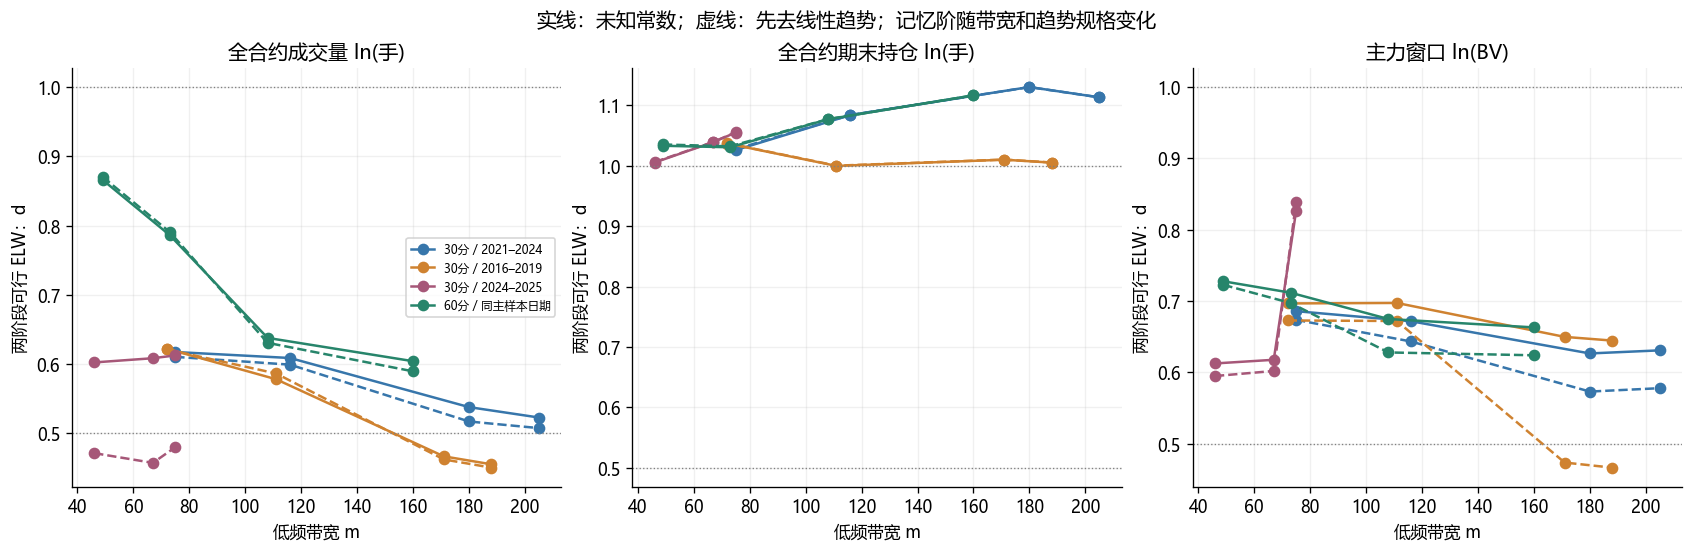

In [14]:
formal_cases = [case for case in analysis_cases if case != "30m_raw_longest"]
elw_rows = []
for case in formal_cases:
    for column in LOG_COLUMNS:
        for m in bandwidths_by_case[case]:
            for trend_order in [0, 1]:
                elw_rows.append(dict(case=case, variable=column,
                    **feasible_elw(analysis_cases[case]["log_df"][column].to_numpy(), m, trend_order)))
    print(f"ELW 完成：{CASE_LABELS[case]}", flush=True)
elw_df = pd.DataFrame(elw_rows)
elw_summary_df = elw_df.groupby(["case", "variable", "trend_order"], sort=False).agg(
    d_min=("d", "min"), d_median=("d", "median"), d_max=("d", "max"),
    initial_d_min=("initial_d", "min"), initial_d_max=("initial_d", "max"),
    numerical_ok_count=("numerical_ok", "sum"), estimates=("d", "size")).reset_index()
display(elw_summary_df.round(4))

common_order_rows = []
common_groups = [
    ("量与BV", [LOG_COLUMNS[0], LOG_COLUMNS[2]]),
    ("量与仓", LOG_COLUMNS[:2]),
    ("仓与BV", LOG_COLUMNS[1:]),
    ("量仓BV", LOG_COLUMNS),
]
for case in formal_cases:
    for m in bandwidths_by_case[case]:
        for trend_order in [0, 1]:
            subset_df = elw_df.loc[elw_df["case"].eq(case) & elw_df["m"].eq(m) & elw_df["trend_order"].eq(trend_order)].set_index("variable")
            for group_label, variables in common_groups:
                selected_df = subset_df.loc[variables]
                quantile = norm.ppf(1 - .05/(2*len(variables)))
                lower = (selected_df["d"] - quantile * selected_df["se_conditional"]).max()
                upper = (selected_df["d"] + quantile * selected_df["se_conditional"]).min()
                numerical_ok = bool(selected_df["numerical_ok"].all())
                common_order_rows.append(dict(case=case, group=group_label, m=m, trend_order=trend_order,
                    d_gap=float(selected_df["d"].max()-selected_df["d"].min()),
                    intersection_lower=float(lower), intersection_upper=float(upper),
                    numerical_ok=numerical_ok, intervals_overlap=bool(numerical_ok and lower <= upper)))
common_order_df = pd.DataFrame(common_order_rows)
primary_bandwidth_by_case = {
    case: min(int(len(analysis_cases[case]["log_df"]) ** .6),
        (len(analysis_cases[case]["log_df"]) - 1) // (4 * analysis_cases[case]["slots_per_day"]))
    for case in formal_cases
}
primary_common_order_df = common_order_df.loc[
    common_order_df["trend_order"].eq(0)
    & common_order_df.apply(lambda row: row["m"] == primary_bandwidth_by_case[row["case"]], axis=1)]
display(primary_common_order_df.round(4))
assert elw_df["numerical_ok"].all(), "存在 ELW 数值异常，须核查后再解释检验结果。"

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
for ax, column in zip(axes, LOG_COLUMNS):
    for case, color in [("30m_slot_longest", "#3776ab"), ("30m_slot_pre2020", "#cf8230"),
                         ("30m_slot_recent", "#a65778"), ("60m_slot_same_dates", "#27856b")]:
        for trend_order, style in [(0, "-"), (1, "--")]:
            selected_df = elw_df.loc[elw_df["case"].eq(case) & elw_df["variable"].eq(column) & elw_df["trend_order"].eq(trend_order)]
            ax.plot(selected_df["m"], selected_df["d"], style, marker="o", color=color,
                label=CASE_LABELS[case] if trend_order == 0 else None)
    ax.axhline(.5, color="grey", ls=":", lw=.8)
    ax.axhline(1, color="grey", ls=":", lw=.8)
    ax.set(title=VARIABLE_LABELS[column], xlabel="低频带宽 m", ylabel="两阶段可行 ELW：d")
    ax.grid(alpha=.18)
axes[0].legend(fontsize=7)
fig.suptitle("实线：未知常数；虚线：先去线性趋势；记忆阶随带宽和趋势规格变化", fontsize=12)
if EXPORT_FILES:
    fig.savefig(output_dir / "testing_14_rb_feasible_elw.png", dpi=160)
plt.show()

## 21. 分数协整检验与有限样本校准

CH06 渐近检验在第 19 节的小样本模拟中过度拒绝，故不能仅凭渐近 p<0.05 宣称协整。这里同时报告模型条件下的渐近概率和**拟合零假设模型的残差 bootstrap 概率**，后者用于有限样本校准，不声称适用于任意市场过程。

零假设模型是两列具有相同 d、满秩创新的分数 VAR：先用主带宽的两列 ELW 均值指定共同 d，以同一个 d 滤波，去掉最初 60 个交易日的初始化影响，再由 BIC 在 0 至两个交易日滞后中选择 VAR。在同一固定日盘时段内，保留同一时刻的二维残差向量进行分层重抽样，保留各时段的方差、厚尾与同期相关性。VAR 的截距用于拟合，模拟中心化短记忆过程；各时段残差池分别定中心，不逐日去均值。模拟先生成带预热的稳定 VAR，再施加共同分数积分，截取与实证相同长度。拟合失败、VAR 不稳定或创新协方差病态时停止解释。

每个样本区间 999 次模拟，固定种子；每次对所有预定频带计算同一个 CH 统计量。使用 \((1+\#\{T^*\ge T\})/(B+1)\)，并报告跨区间、特征向量带宽和频带的 Holm 调整。此 bootstrap 仍条件于估计的共同 d 与有限阶 VAR，不包含参数估计不确定性的完整理论保证。共同阶区间没有交集时，概率仅用于显示模型失配，不能解释为协整证据。

本节用同一分数差分只是拟合“无协整”的模拟模型；实证 CH 检验始终作用于原对数水平的共同整数差分与 taper。没有把三列各自变平稳后再把相关回归称作协整。

另报告 VAR 残差的 Portmanteau 检查和每日滞后的相关性。残差检查拒绝时，bootstrap 只能视为该拟合模型的校准结果，不具有市场过程下的准确尺寸保证。

In [15]:
BOOTSTRAP_REPLICATIONS = 999
ch_empirical_rows = []
null_model_rows = []
bootstrap_ch_rows = []
bootstrap_started_at = time.perf_counter()
bootstrap_rng = np.random.default_rng(2026100402)
bootstrap_cases = ["30m_slot_longest", "30m_slot_pre2020", "30m_slot_2020",
    "30m_slot_recent", "60m_slot_same_dates", "60m_slot_recent"]

with threadpool_limits(limits=1):
    for case in bootstrap_cases:
        case_info = analysis_cases[case]
        values = case_info["log_df"][[LOG_COLUMNS[0], LOG_COLUMNS[2]]].to_numpy()
        n, seasonal_period = len(values), case_info["slots_per_day"]
        maximum_frequency = (n - 1) // (4 * seasonal_period)
        test_specs = []
        for m_peri in [10, 20]:
            available_bins = maximum_frequency - (m_peri + 2) + 1
            memory_bin_choices = sorted({
                min(int((n - 1) ** exponent), available_bins) for exponent in [.55, .60, .65]
            })
            for memory_bins in memory_bin_choices:
                if memory_bins >= 15:
                    test_specs.append((m_peri, memory_bins))
                    test_result = chen_hurvich_test(values, m_peri, memory_bins)
                    ch_empirical_rows.append(dict(case=case, **test_result))
        primary_m = primary_bandwidth_by_case[case]
        primary_elw_df = elw_df.loc[
            elw_df["case"].eq(case) & elw_df["m"].eq(primary_m) & elw_df["trend_order"].eq(0)
            & elw_df["variable"].isin([LOG_COLUMNS[0], LOG_COLUMNS[2]])]
        common_d = float(primary_elw_df["d"].mean())
        filtered_values = np.column_stack([
            fractional_difference(values[:, column] - values[:, column].mean(), common_d)
            for column in range(2)])
        burn_in = 60 * seasonal_period
        filtered_values = filtered_values[burn_in:]
        order_selection = VAR(filtered_values).select_order(maxlags=2*seasonal_period, trend="c")
        var_order = int(order_selection.selected_orders["bic"])
        var_fit = VAR(filtered_values).fit(var_order, trend="c")
        if var_order:
            companion = np.zeros((2*var_order, 2*var_order))
            companion[:2] = np.concatenate(var_fit.coefs, axis=1)
            if var_order > 1: companion[2:, :-2] = np.eye(2*(var_order-1))
            spectral_radius = float(np.max(np.abs(np.linalg.eigvals(companion))))
        else:
            spectral_radius = 0.
        residuals = np.asarray(var_fit.resid)
        residuals -= residuals.mean(axis=0)
        residual_slots = case_info["grid_df"]["slot"].iloc[burn_in + var_order:].to_numpy()
        residual_pools = []
        for slot in WINDOW_SLOTS_BY_WIDTH[case_info["width"]]:
            pool = residuals[residual_slots == slot].copy()
            pool -= pool.mean(axis=0)
            if len(pool) < 20: raise ValueError("分时段残差池过小。")
            residual_pools.append(pool)
        residual_covariance = np.cov(residuals, rowvar=False)
        portmanteau = var_fit.test_whiteness(nlags=max(2*seasonal_period+1, var_order+5), adjusted=True)
        residual_acf_daily = max(abs(acf(residuals[:, j], nlags=seasonal_period, fft=True)[seasonal_period]) for j in [0, 1])
        covariance_condition = float(np.linalg.cond(residual_covariance))
        if spectral_radius >= .995 or covariance_condition > 1e6:
            raise ValueError(f"{case} 零假设模型不适合模拟：VAR 半径 {spectral_radius}，协方差条件数 {covariance_condition}")
        common_row = primary_common_order_df.loc[
            primary_common_order_df["case"].eq(case) & primary_common_order_df["group"].eq("量与BV")].iloc[0]
        null_model_rows.append(dict(case=case, n=n, common_d=common_d,
            volume_d=float(primary_elw_df.set_index("variable").loc[LOG_COLUMNS[0], "d"]),
            bv_d=float(primary_elw_df.set_index("variable").loc[LOG_COLUMNS[2], "d"]),
            primary_intervals_overlap=bool(common_row["intervals_overlap"]),
            var_order=var_order, spectral_radius=spectral_radius,
            covariance_condition=covariance_condition,
            innovation_correlation=float(np.corrcoef(residuals.T)[0, 1]),
            filter_burn_in=burn_in, bootstrap_replications=BOOTSTRAP_REPLICATIONS,
            var_portmanteau_p=float(portmanteau.pvalue), residual_acf_daily_max=float(residual_acf_daily),
            innovation_sampling="fixed-slot vector residual bootstrap"))
        # 批量生成独立路径，按时间递推 VAR；同一行二维残差作为整体重抽。
        warmup = ((max(512, 20*seasonal_period) + seasonal_period - 1) // seasonal_period) * seasonal_period
        simulation_length = n + warmup
        sampled_residuals = np.empty((BOOTSTRAP_REPLICATIONS, simulation_length, 2))
        for slot_index, pool in enumerate(residual_pools):
            time_positions = np.arange(slot_index, simulation_length, seasonal_period)
            sampled_indices = bootstrap_rng.integers(len(pool), size=(BOOTSTRAP_REPLICATIONS, len(time_positions)))
            sampled_residuals[:, time_positions] = pool[sampled_indices]
        simulated_short_memory = np.zeros_like(sampled_residuals)
        for t in range(simulation_length):
            simulated_short_memory[:, t] = sampled_residuals[:, t]
            for lag in range(1, min(var_order, t) + 1):
                simulated_short_memory[:, t] += simulated_short_memory[:, t-lag] @ var_fit.coefs[lag-1].T
        integration_weights = np.r_[1., np.cumprod(
            (np.arange(1, simulation_length) - 1 + common_d) / np.arange(1, simulation_length))]
        simulated_levels = fftconvolve(simulated_short_memory, integration_weights[None, :, None],
            mode="full", axes=1)[:, :simulation_length, :][:, -n:, :]
        for replication, simulated_values in enumerate(simulated_levels):
            for m_peri, memory_bins in test_specs:
                simulated_test = chen_hurvich_test(simulated_values, m_peri, memory_bins)
                bootstrap_ch_rows.append(dict(case=case, replication=replication, m_peri=m_peri,
                    memory_bins=memory_bins, statistic=simulated_test["statistic"], boundary=simulated_test["boundary"]))
        del sampled_residuals, simulated_short_memory, simulated_levels, sampled_indices
        print(f"有限样本校准完成：{CASE_LABELS[case]}，{BOOTSTRAP_REPLICATIONS} 次；总耗时 {time.perf_counter()-bootstrap_started_at:.1f}s", flush=True)

ch_empirical_df = pd.DataFrame(ch_empirical_rows)
null_model_df = pd.DataFrame(null_model_rows)
bootstrap_ch_df = pd.DataFrame(bootstrap_ch_rows)
for index, row in ch_empirical_df.iterrows():
    simulated_df = bootstrap_ch_df.loc[
        bootstrap_ch_df["case"].eq(row["case"]) & bootstrap_ch_df["m_peri"].eq(row["m_peri"])
        & bootstrap_ch_df["memory_bins"].eq(row["memory_bins"])]
    boundary_rate = simulated_df["boundary"].mean()
    # 保留模拟中全部统计量，不通过删边界路径人为改变尾部；边界率过高则不解释。
    bootstrap_p = (1 + simulated_df["statistic"].ge(row["statistic"]).sum())/(1 + len(simulated_df))
    ch_empirical_df.loc[index, "bootstrap_p_conditional"] = bootstrap_p if not row["boundary"] and boundary_rate < .05 else np.nan
    ch_empirical_df.loc[index, "bootstrap_critical_95"] = simulated_df["statistic"].quantile(.95)
    ch_empirical_df.loc[index, "bootstrap_boundary_rate"] = boundary_rate
valid_probabilities = ch_empirical_df["bootstrap_p_conditional"].notna()
ch_empirical_df.loc[valid_probabilities, "bootstrap_p_holm"] = multipletests(
    ch_empirical_df.loc[valid_probabilities, "bootstrap_p_conditional"], method="holm")[1]
ch_empirical_df = ch_empirical_df.merge(
    null_model_df[["case", "primary_intervals_overlap"]], on="case", validate="many_to_one")
ch_empirical_df["conditional_reject_holm"] = (
    ch_empirical_df["bootstrap_p_holm"].lt(.05) & ch_empirical_df["primary_intervals_overlap"])
display(null_model_df.round(4))
display(ch_empirical_df[[
    "case", "m_peri", "memory_bins", "d_large", "d_small", "memory_drop",
    "pvalue_conditional", "bootstrap_p_conditional", "bootstrap_p_holm",
    "primary_intervals_overlap", "conditional_reject_holm"]].round(4))
print("校准概率条件于拟合零假设模型；未拒绝不证明无协整，拒绝也须满足共同阶及结构稳定性条件。")

有限样本校准完成：30分 / 2021–2024，999 次；总耗时 15.8s


有限样本校准完成：30分 / 2016–2019，999 次；总耗时 29.4s


有限样本校准完成：30分 / 2020，999 次；总耗时 33.9s


有限样本校准完成：30分 / 2024–2025，999 次；总耗时 38.7s


有限样本校准完成：60分 / 同主样本日期，999 次；总耗时 52.3s


有限样本校准完成：60分 / 2024–2025，999 次；总耗时 62.7s


,case,n,common_d,volume_d,bv_d,primary_intervals_overlap,var_order,spectral_radius,covariance_condition,innovation_correlation,filter_burn_in,bootstrap_replications,var_portmanteau_p,residual_acf_daily_max,innovation_sampling
0,30m_slot_longest,5747,0.5821,0.5377,0.6264,True,6,0.7283,5.0744,0.6424,420,999,0.0000,0.0637,fixed-slot vector residual bootstrap
1,30m_slot_pre2020,5271,0.5581,0.4666,0.6496,False,9,0.7816,5.9864,0.6957,420,999,0.0731,0.0089,fixed-slot vector residual bootstrap
2,30m_slot_2020,1519,0.5938,0.5895,0.5982,True,3,0.5575,6.7281,0.7243,420,999,0.0000,0.0327,fixed-slot vector residual bootstrap
3,30m_slot_recent,2128,0.7193,0.6124,0.8262,True,6,0.7671,4.2943,0.6029,420,999,0.0001,0.0781,fixed-slot vector residual bootstrap
4,60m_slot_same_dates,2463,0.6562,0.6377,0.6747,True,4,0.6111,6.1837,0.7077,180,999,0.0000,0.0341,fixed-slot vector residual bootstrap
5,60m_slot_recent,912,0.7071,0.6029,0.8113,True,3,0.6455,5.9257,0.7094,180,999,0.0018,0.0573,fixed-slot vector residual bootstrap


,case,m_peri,memory_bins,d_large,d_small,memory_drop,pvalue_conditional,bootstrap_p_conditional,bootstrap_p_holm,primary_intervals_overlap,conditional_reject_holm
0,30m_slot_longest,10,116,0.5582,0.3769,0.1814,0.0241,0.077,1.000,True,False
1,30m_slot_longest,10,180,0.4057,0.3060,0.0997,0.1225,0.144,1.000,True,False
2,30m_slot_longest,10,194,0.4230,0.3414,0.0816,0.1893,0.172,1.000,True,False
3,30m_slot_longest,20,116,0.5469,0.3510,0.1959,0.0148,0.119,1.000,True,False
4,30m_slot_longest,20,180,0.3599,0.2902,0.0697,0.2803,0.271,1.000,True,False
5,30m_slot_longest,20,184,0.3773,0.3013,0.0760,0.2341,0.240,1.000,True,False
6,30m_slot_pre2020,10,111,0.6501,0.4977,0.1524,0.0637,0.115,1.000,False,False
7,30m_slot_pre2020,10,171,0.4524,0.3803,0.0721,0.2761,0.209,1.000,False,False
8,30m_slot_pre2020,10,177,0.4539,0.3862,0.0677,0.2980,0.236,1.000,False,False
9,30m_slot_pre2020,20,111,0.4312,0.2861,0.1451,0.0775,0.171,1.000,False,False


校准概率条件于拟合零假设模型；未拒绝不证明无协整，拒绝也须满足共同阶及结构稳定性条件。


### 21.1 短期模型敏感性：完整交易日块重抽样

低阶 VAR 的残差检验在多数区间拒绝。为检查独立抽样是否遗漏短期依赖，另外将中心化残差按完整交易日组成 5 日、10 日重叠块，按块重抽样。每条路径的日盘时段顺序保持一致；块内跨变量、跨窗口和跨日依赖均保留。

仍使用第 21 节的共同 d 和 VAR 系数，每个区间、每种块长度各 999 次，仅检验预先指定的主频带。检查块和协方差满秩，避免把退化共同冲击直接当作无协整模型。它是对短期依赖建模的敏感性，不是一般分数过程下的无条件有效 bootstrap；有限块也不能保留任意长的结构变化或记忆。

In [16]:
block_bootstrap_rng = np.random.default_rng(2026100403)
block_bootstrap_started_at = time.perf_counter()
block_test_rows = []
block_statistic_rows = []
with threadpool_limits(limits=1):
    for case in bootstrap_cases:
        case_info = analysis_cases[case]
        values = case_info["log_df"][[LOG_COLUMNS[0], LOG_COLUMNS[2]]].to_numpy()
        n, seasonal_period = len(values), case_info["slots_per_day"]
        model_row = null_model_df.set_index("case").loc[case]
        common_d, var_order = float(model_row["common_d"]), int(model_row["var_order"])
        filtered_values = np.column_stack([
            fractional_difference(values[:, j] - values[:, j].mean(), common_d) for j in [0, 1]
        ])[60*seasonal_period:]
        var_fit = VAR(filtered_values).fit(var_order, trend="c")
        residuals = np.asarray(var_fit.resid)
        first_full_day_offset = (-var_order) % seasonal_period
        usable_length = ((len(residuals)-first_full_day_offset)//seasonal_period)*seasonal_period
        residual_days = residuals[first_full_day_offset:first_full_day_offset+usable_length].reshape(-1, seasonal_period, 2).copy()
        residual_days -= residual_days.mean(axis=0)
        warmup = ((max(512, 20*seasonal_period)+seasonal_period-1)//seasonal_period)*seasonal_period
        simulation_length = n+warmup
        simulated_day_count = (simulation_length+seasonal_period-1)//seasonal_period
        memory_bins = min(int((n-1)**.6), (n-1)//(4*seasonal_period)-21)
        observed_test = chen_hurvich_test(values, 20, memory_bins)
        for block_days in [5, 10]:
            block_sums = np.array([residual_days[i:i+block_days].sum(axis=(0,1))
                for i in range(len(residual_days)-block_days+1)])
            block_sum_covariance = np.cov(block_sums, rowvar=False)
            block_condition = float(np.linalg.cond(block_sum_covariance))
            if np.linalg.eigvalsh(block_sum_covariance).min() <= 0 or block_condition > 1e6:
                raise ValueError(f"{case} 的日块零频协方差退化，不能作为无协整校准模型。")
            blocks_per_path = (simulated_day_count+block_days-1)//block_days
            block_starts = block_bootstrap_rng.integers(len(residual_days)-block_days+1,
                size=(BOOTSTRAP_REPLICATIONS, blocks_per_path))
            sampled_days = (block_starts[:,:,None]+np.arange(block_days)).reshape(BOOTSTRAP_REPLICATIONS,-1)[:,:simulated_day_count]
            sampled_residuals = residual_days[sampled_days].reshape(BOOTSTRAP_REPLICATIONS,-1,2)[:,:simulation_length]
            simulated_short_memory = np.zeros_like(sampled_residuals)
            for t in range(simulation_length):
                simulated_short_memory[:,t] = sampled_residuals[:,t]
                for lag in range(1,min(var_order,t)+1):
                    simulated_short_memory[:,t] += simulated_short_memory[:,t-lag] @ var_fit.coefs[lag-1].T
            integration_weights = np.r_[1.,np.cumprod(
                (np.arange(1,simulation_length)-1+common_d)/np.arange(1,simulation_length))]
            simulated_levels = fftconvolve(simulated_short_memory,integration_weights[None,:,None],
                mode="full",axes=1)[:,:simulation_length,:][:,-n:,:]
            statistics, boundary_flags = [], []
            for replication, simulated_values in enumerate(simulated_levels):
                test = chen_hurvich_test(simulated_values,20,memory_bins)
                statistics.append(test["statistic"])
                boundary_flags.append(test["boundary"])
                block_statistic_rows.append(dict(case=case,block_days=block_days,replication=replication,
                    statistic=test["statistic"],boundary=test["boundary"]))
            probability = (1+np.sum(np.asarray(statistics)>=observed_test["statistic"]))/(BOOTSTRAP_REPLICATIONS+1)
            block_test_rows.append(dict(case=case,block_days=block_days,memory_bins=memory_bins,
                bootstrap_p_conditional=float(probability) if not observed_test["boundary"] and np.mean(boundary_flags)<.05 else np.nan,
                critical_95=float(np.quantile(statistics,.95)),boundary_rate=float(np.mean(boundary_flags)),
                block_sum_covariance_condition=block_condition,
                common_order_compatible=bool(model_row["primary_intervals_overlap"])))
            del sampled_residuals,simulated_short_memory,simulated_levels
        print(f"日块敏感性完成：{CASE_LABELS[case]}；累计 {time.perf_counter()-block_bootstrap_started_at:.1f}s",flush=True)
block_test_df = pd.DataFrame(block_test_rows)
block_statistics_df = pd.DataFrame(block_statistic_rows)
valid_blocks = block_test_df["bootstrap_p_conditional"].notna()
block_test_df.loc[valid_blocks,"bootstrap_p_holm_12"] = multipletests(
    block_test_df.loc[valid_blocks,"bootstrap_p_conditional"],method="holm")[1]
block_test_df["conditional_reject_holm"] = block_test_df["bootstrap_p_holm_12"].lt(.05) & block_test_df["common_order_compatible"]
display(block_test_df.round(4))

日块敏感性完成：30分 / 2021–2024；累计 6.5s


日块敏感性完成：30分 / 2016–2019；累计 13.1s


日块敏感性完成：30分 / 2020；累计 18.1s


日块敏感性完成：30分 / 2024–2025；累计 24.0s


日块敏感性完成：60分 / 同主样本日期；累计 29.1s


日块敏感性完成：60分 / 2024–2025；累计 33.4s


,case,block_days,memory_bins,bootstrap_p_conditional,critical_95,boundary_rate,block_sum_covariance_condition,common_order_compatible,bootstrap_p_holm_12,conditional_reject_holm
0,30m_slot_longest,5,180,0.510,3.5516,0.0000,7.1396,True,1.0,False
1,30m_slot_longest,10,180,0.644,4.0613,0.0000,7.5583,True,1.0,False
2,30m_slot_pre2020,5,167,0.639,2.7297,0.0000,6.1404,False,1.0,False
3,30m_slot_pre2020,10,167,0.700,3.3577,0.0000,5.5522,False,1.0,False
4,30m_slot_2020,5,33,NaN,5.0572,0.1361,11.2992,True,NaN,False
5,30m_slot_2020,10,33,NaN,2.9459,0.3634,17.3681,True,NaN,False
6,30m_slot_recent,5,54,0.687,5.0490,0.0000,5.8122,True,1.0,False
7,30m_slot_recent,10,54,0.646,5.0520,0.0000,7.0897,True,1.0,False
8,60m_slot_same_dates,5,108,0.185,3.8151,0.0000,6.6370,True,1.0,False
9,60m_slot_same_dates,10,108,0.255,4.0710,0.0000,7.1366,True,1.0,False


## 22. 校准结果、最终解释与复核文件

主检验规格固定为 m₀=20、记忆频点数由 n^0.6 与季节频率上限决定。对六个区间的主规格另作 Holm 校正；第 21 节全部 26 个敏感性规格的 Holm 校正也完整保留。两者不能混淆，不能从敏感性表中挑最小概率充当预先指定的主检验。

最终解释结合共同阶诊断、有限样本校准和跨时期稳定性。bootstrap 重抽样按照固定交易时段分层，仍以拟合的分数 VAR 为条件；它不是无假设的证明。未拒绝无协整不等于证明不存在协整，阶数不同也不排除其他子系统或频率上的关系。

,case,actual_start,actual_end,selected_windows,memory_bins,pvalue_conditional,bootstrap_p_conditional,bootstrap_p_holm_primary,primary_intervals_overlap,conditional_reject_holm_primary
0,30m_slot_longest,2021-05-17,2024-09-27,5747,180,0.2803,0.271,1.000,True,False
1,30m_slot_pre2020,2016-12-01,2019-12-31,5271,167,1.0000,0.589,1.000,False,False
2,30m_slot_2020,2020-02-04,2020-12-18,1519,33,1.0000,0.793,1.000,True,False
3,30m_slot_recent,2024-10-08,2025-12-31,2128,54,1.0000,0.511,1.000,True,False
4,60m_slot_same_dates,2021-05-17,2024-09-27,2463,108,0.0075,0.111,0.666,True,False
5,60m_slot_recent,2024-10-08,2025-12-31,912,54,0.8720,0.468,1.000,True,False


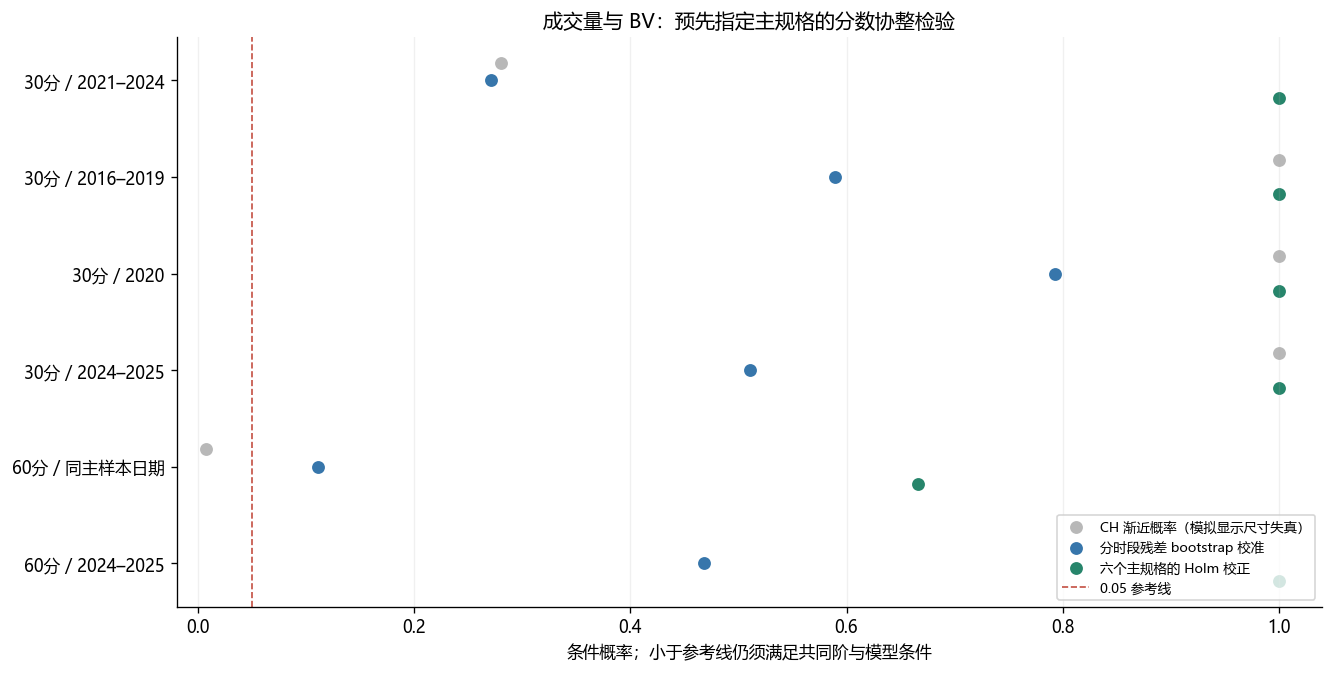

variable,ln_bipower_variation,ln_total_open_interest,ln_total_volume
case,,,
30m_slot_2020,0.5982,1.0857,0.5895
30m_slot_longest,0.6264,1.1305,0.5377
30m_slot_pre2020,0.6496,1.0101,0.4666
30m_slot_recent,0.8262,1.0551,0.6124
60m_slot_longest,0.6831,1.0232,0.7414
60m_slot_recent,0.8113,1.0396,0.6029
60m_slot_same_dates,0.6747,1.0771,0.6377


,day_block_5_p,day_block_10_p,slot_iid_p
case,,,
30m_slot_2020,NaN,NaN,0.793
30m_slot_longest,0.510,0.644,0.271
30m_slot_pre2020,0.639,0.700,0.589
30m_slot_recent,0.687,0.646,0.511
60m_slot_recent,0.649,0.613,0.468
60m_slot_same_dates,0.185,0.255,0.111



**当前证据仍不足以确认跨时期稳定的量、仓、BV 三变量协整关系。**

1. 主样本 2021-05-17—2024-09-27、30 分钟、常数规格的 ELW 估计：成交量 d=0.538，持仓 d=1.130，BV d=0.626。7 个区间/窗口规格中，三列共同阶同时区间有交集的规格为 0 个。这不支持直接套用标准共同阶三变量 FCVAR。
2. 成交量与 BV 的主样本 bootstrap 概率为 **0.271**；同日期 60 分钟为 **0.111**。六个主规格经 Holm 校正后，符合共同阶诊断且拒绝无协整的为 **0 个**；全部 26 个敏感性规格为 **0 个**。
3. 模拟中名义 5% 的 CH 渐近检验，在同阶无协整的三个场景中拒绝率为 15.5%～22.5%；不能只凭实证的渐近显著性下结论。异阶无共同趋势的反例也会大量拒绝，说明同阶前提不可省略。
4. 近期个别频带的未校正概率可能较小，但频带、时间窗口和时期的敏感性，以及前述持仓系数变动，都不支持将其解释为稳定长期均衡。
5. 6 个校准模型中，有 5 个的 VAR 残差 Portmanteau 检查在 5% 水平拒绝。bootstrap 是给定模型的有限样本校准，不能据此宣称完全消除了市场数据的模型误设或参数不确定性。

完整交易日块敏感性：5 日与 10 日块的 12 个主规格中，经 Holm 校正且满足共同阶诊断的拒绝数为 0。该结果与分时段独立残差校准一起判断，不能只挑一个块长度。

已执行的是两阶段可行 ELW、CH06 及其条件校准；没有运行 FCVAR、FMNBLS 或周期分数阶协整。尤其不能把持仓一阶差分与原水平量/BV 混在一起，再把得到的关系称为原三变量协整。


ELW 150 组，算法模拟 1192 次，零假设路径 17,982 条（含两种日块校准），CH 规格 26 个。


In [17]:
ch_empirical_df["primary_specification"] = ch_empirical_df.apply(
    lambda row: row["m_peri"] == 20 and row["memory_bins"] == min(
        int((len(analysis_cases[row["case"]]["log_df"]) - 1) ** .6),
        (len(analysis_cases[row["case"]]["log_df"]) - 1) // (4*analysis_cases[row["case"]]["slots_per_day"]) - 21),
    axis=1)
primary_ch_df = ch_empirical_df.loc[ch_empirical_df["primary_specification"]].copy()
assert len(primary_ch_df) == len(bootstrap_cases)
valid_primary = primary_ch_df["bootstrap_p_conditional"].notna()
primary_ch_df.loc[valid_primary, "bootstrap_p_holm_primary"] = multipletests(
    primary_ch_df.loc[valid_primary, "bootstrap_p_conditional"], method="holm")[1]
primary_ch_df["conditional_reject_holm_primary"] = (
    primary_ch_df["bootstrap_p_holm_primary"].lt(.05) & primary_ch_df["primary_intervals_overlap"])
primary_ch_df = primary_ch_df.merge(
    sample_summary_df[["case", "actual_start", "actual_end", "selected_windows"]], on="case", validate="one_to_one")
display(primary_ch_df[[
    "case", "actual_start", "actual_end", "selected_windows", "memory_bins",
    "pvalue_conditional", "bootstrap_p_conditional", "bootstrap_p_holm_primary",
    "primary_intervals_overlap", "conditional_reject_holm_primary"]].round(4))

fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
positions = np.arange(len(primary_ch_df))
for column, label, color, offset in [
    ("pvalue_conditional", "CH 渐近概率（模拟显示尺寸失真）", "#b8b8b8", -.18),
    ("bootstrap_p_conditional", "分时段残差 bootstrap 校准", "#3776ab", 0.),
    ("bootstrap_p_holm_primary", "六个主规格的 Holm 校正", "#27856b", .18),
]:
    ax.scatter(primary_ch_df[column], positions+offset, s=45, label=label, color=color)
ax.axvline(.05, color="#c34f42", ls="--", lw=1, label="0.05 参考线")
ax.set_yticks(positions, [CASE_LABELS[c] for c in primary_ch_df["case"]])
ax.set(xlim=(-.02, 1.04), xlabel="条件概率；小于参考线仍须满足共同阶与模型条件",
    title="成交量与 BV：预先指定主规格的分数协整检验")
ax.invert_yaxis()
ax.grid(axis="x", alpha=.18)
ax.legend(loc="lower right", fontsize=8)
if EXPORT_FILES:
    fig.savefig(output_dir / "testing_14_rb_fractional_test_calibration.png", dpi=160)
plt.show()

primary_elw_d_df = elw_df.loc[
    elw_df["trend_order"].eq(0)
    & elw_df.apply(lambda row: row["m"] == primary_bandwidth_by_case[row["case"]], axis=1)
].pivot(index="case", columns="variable", values="d")
display(primary_elw_d_df.round(4))
block_probability_comparison_df = block_test_df.pivot(index="case", columns="block_days", values="bootstrap_p_conditional")
block_probability_comparison_df.columns = ["day_block_5_p", "day_block_10_p"]
block_probability_comparison_df = block_probability_comparison_df.join(primary_ch_df.set_index("case")["bootstrap_p_conditional"].rename("slot_iid_p"))
display(block_probability_comparison_df.round(4))
primary_main_test = primary_ch_df.set_index("case").loc["30m_slot_longest"]
primary_same_dates_test = primary_ch_df.set_index("case").loc["60m_slot_same_dates"]
main_d = primary_elw_d_df.loc["30m_slot_longest"]
simulated_null_summary = ch_validation_summary_df.loc[ch_validation_summary_df["scenario"].str.startswith("同阶无协整")]
all_spec_rejections = int(ch_empirical_df["conditional_reject_holm"].sum())
primary_rejections = int(primary_ch_df["conditional_reject_holm_primary"].sum())
common_triple_diagnostics = primary_common_order_df.loc[primary_common_order_df["group"].eq("量仓BV")]
whiteness_rejections = int(null_model_df["var_portmanteau_p"].lt(.05).sum())
display(Markdown(f"""
**当前证据仍不足以确认跨时期稳定的量、仓、BV 三变量协整关系。**

1. 主样本 2021-05-17—2024-09-27、30 分钟、常数规格的 ELW 估计：成交量 d={main_d['ln_total_volume']:.3f}，持仓 d={main_d['ln_total_open_interest']:.3f}，BV d={main_d['ln_bipower_variation']:.3f}。{len(common_triple_diagnostics)} 个区间/窗口规格中，三列共同阶同时区间有交集的规格为 {int(common_triple_diagnostics['intervals_overlap'].sum())} 个。这不支持直接套用标准共同阶三变量 FCVAR。
2. 成交量与 BV 的主样本 bootstrap 概率为 **{primary_main_test['bootstrap_p_conditional']:.3f}**；同日期 60 分钟为 **{primary_same_dates_test['bootstrap_p_conditional']:.3f}**。六个主规格经 Holm 校正后，符合共同阶诊断且拒绝无协整的为 **{primary_rejections} 个**；全部 {len(ch_empirical_df)} 个敏感性规格为 **{all_spec_rejections} 个**。
3. 模拟中名义 5% 的 CH 渐近检验，在同阶无协整的三个场景中拒绝率为 {simulated_null_summary['rejection_rate'].min():.1%}～{simulated_null_summary['rejection_rate'].max():.1%}；不能只凭实证的渐近显著性下结论。异阶无共同趋势的反例也会大量拒绝，说明同阶前提不可省略。
4. 近期个别频带的未校正概率可能较小，但频带、时间窗口和时期的敏感性，以及前述持仓系数变动，都不支持将其解释为稳定长期均衡。
5. {len(null_model_df)} 个校准模型中，有 {whiteness_rejections} 个的 VAR 残差 Portmanteau 检查在 5% 水平拒绝。bootstrap 是给定模型的有限样本校准，不能据此宣称完全消除了市场数据的模型误设或参数不确定性。

完整交易日块敏感性：5 日与 10 日块的 12 个主规格中，经 Holm 校正且满足共同阶诊断的拒绝数为 {int(block_test_df["conditional_reject_holm"].sum())}。该结果与分时段独立残差校准一起判断，不能只挑一个块长度。

已执行的是两阶段可行 ELW、CH06 及其条件校准；没有运行 FCVAR、FMNBLS 或周期分数阶协整。尤其不能把持仓一阶差分与原水平量/BV 混在一起，再把得到的关系称为原三变量协整。
"""))

formal_results = {
    "configuration": {
        "notebook": "testing_14.ipynb", "primary_window_minutes": 30,
        "robustness_window_minutes": 60, "source_end": "2025-12-31",
        "roll_trigger_ratio": 1.0, "bootstrap_replications_per_case": BOOTSTRAP_REPLICATIONS,
        "bootstrap_seed": 2026100402, "validation_seed": 2026100401,
        "day_block_seed": 2026100403, "day_block_lengths": [5, 10],
        "null_bootstrap_model": "common-d fractional VAR; BIC lag selection; fixed-slot vector residual resampling",
        "inference_scope": "conditional on common integration order and fitted short-memory model; not a model-free proof",
        "author_elwcode10_sha256": "adb3e59fbd4fc3f76993162b02b462459c430ad859f40612e547d3ac54f743cf",
    }
}
for name, table_df in {
    "elw_estimates": elw_df, "elw_summary": elw_summary_df,
    "common_order_diagnostics": common_order_df, "primary_common_order": primary_common_order_df,
    "elw_validation": elw_simulation_df, "elw_validation_summary": elw_validation_summary_df,
    "ch_validation": ch_simulation_df, "ch_validation_summary": ch_validation_summary_df,
    "null_models": null_model_df, "ch_tests": ch_empirical_df, "primary_ch_tests": primary_ch_df,
    "bootstrap_statistics": bootstrap_ch_df,
    "day_block_tests": block_test_df, "day_block_statistics": block_statistics_df,
}.items():
    formal_results[name] = json.loads(table_df.to_json(orient="records", force_ascii=False))
formal_results_path = output_dir / "testing_14_rb_fractional_formal_results.json"
if EXPORT_FILES:
    formal_results_path.write_text(json.dumps(formal_results, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
    assert json.loads(formal_results_path.read_text(encoding="utf-8")) == formal_results
    print(f"已保存并复读核对：{formal_results_path.name}")
print(f"ELW {len(elw_df)} 组，算法模拟 {len(elw_simulation_df)+len(ch_simulation_df)} 次，零假设路径 {3*len(bootstrap_cases)*BOOTSTRAP_REPLICATIONS:,} 条（含两种日块校准），CH 规格 {len(ch_empirical_df)} 个。")
